In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
# from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import read_hatch

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = True

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-02-02'
sample = 'randomsample500' # 'all' 

## Read timeseries stats

In [2]:
stats = pd.read_csv(f"./results/timeseries_stats_all_2024-11-19.csv", index_col=0)
print(len(stats))
stats.head()

5547


,n,dt_mean,dt_std,y_median,y_mean,y_std,y_min,y_max,y_min_rel_pos,y_max_rel_pos,...,lastm,lastm_convexity_sign,lastm_convexity_mean,lastm_convexity_pvalue,lastm_slope_sign,lastm_slope_mean,lastm_lin_pvalue,ratio_last1m_v_first,tech_name,Technology Name
0,254,1.027668,0.439216,56.5,108.755551,118.731352,13.0,508.0,0.616601,0.826087,...,50,-1.0,-0.0016,1.124513e-16,-1.0,-6.4435,9.056352e-17,-1.423208,Sugar Output_Annual Production_JM,Cane Sugar
1,233,1.120690,0.957324,44.0,55.987124,49.107002,2.0,208.0,0.120690,0.771552,...,46,-1.0,-0.0008,1.514871e-21,-1.0,-3.1896,1.229669e-21,-6.680000,Sugar Output_Annual Production_BB,Cane Sugar
2,203,1.108911,0.756503,1190.0,2502.532020,2523.556809,12.0,8538.0,0.004950,0.801980,...,40,-1.0,-0.0403,8.160255e-09,-1.0,-160.2683,8.943426e-09,-4.315130,Sugar Output_Annual Production_CU,Cane Sugar
3,202,1.263682,3.523217,39825.5,30535.928218,25391.445837,864.0,73622.0,0.119403,1.000000,...,40,1.0,0.0790,2.323501e-05,1.0,313.7947,2.212465e-05,0.384759,Beer_Annual Production_GB,Beer Production
4,198,1.000000,0.000000,195.0,273.208020,226.845756,0.2,731.0,0.005076,0.827411,...,39,-1.0,-0.0015,1.463386e-06,-1.0,-5.8404,1.506274e-06,-0.571948,Sugar Output_Annual Production_MU,Cane Sugar


<Axes: >

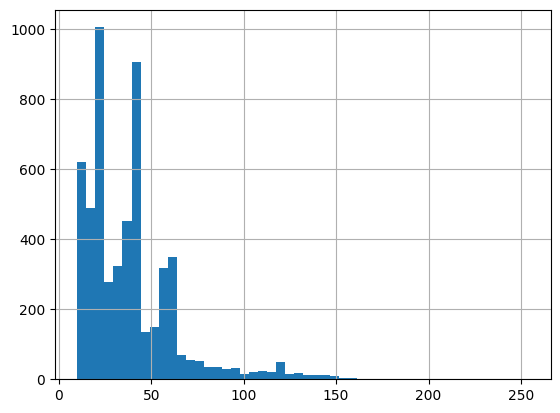

In [ ]:
stats['n'].hist(bins=50)

<Axes: >

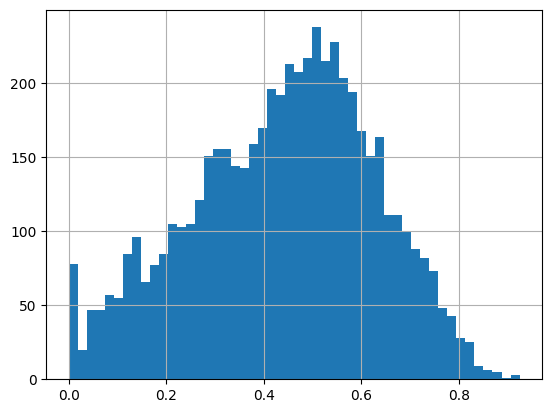

In [ ]:
stats['roughness'].hist(bins=50)

In [ ]:
# roughness seems to be ill-defined for short timeseries
stats[stats['roughness'] > 1]

,n,dt_mean,dt_std,y_median,y_mean,y_std,y_min,y_max,y_min_rel_pos,y_max_rel_pos,...,lastm,lastm_convexity_sign,lastm_convexity_mean,lastm_convexity_pvalue,lastm_slope_sign,lastm_slope_mean,lastm_lin_pvalue,ratio_last1m_v_first,tech_name,Technology Name


## Read fit parameters

In [2]:
fit_params = pd.read_csv(f"./results/fitting_parameters_all_2024-11-19.csv", index_col=[0])
print(len(fit_params))
fit_params.columns

49923


Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Technology Name', 'd', 'd_std', 'error_type',
       'error_msg'],
      dtype='object')

In [ ]:
fit_params.groupby('functional_form')['technology'].count()

functional_form
bass                    5547
bertalanffy             5547
exponential             5547
gompertz                5547
linear                  5547
logistic                5547
logistic-linear-cont    5547
richards                5547
softplus                5547
Name: technology, dtype: int64

## Fit success

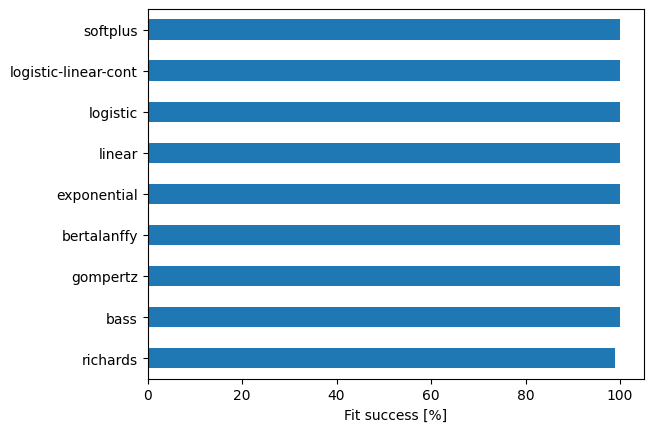

In [37]:
fit_success = 100 * fit_params.groupby('functional_form')['fit_success'].mean()
fit_success.sort_values().plot.barh()
plt.xlabel('Fit success [%]')
plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_fit_success.png', **savefig_settings)

In [9]:
fp_stats = pd.merge(fit_params, stats, left_on='technology', right_on='tech_name', how='left')
print(len(fp_stats))

49923


In [10]:
# mean length of underlying time series
fp_stats.groupby(['functional_form', 'fit_success'])['n'].mean()

functional_form       fit_success
bass                  False          18.000000
                      True           38.773990
bertalanffy           True           38.762755
exponential           True           38.762755
gompertz              False          18.000000
                      True           38.773990
linear                True           38.762755
logistic              True           38.762755
logistic-linear-cont  True           38.762755
richards              False          12.245283
                      True           39.018566
softplus              True           38.762755
Name: n, dtype: float64

In [11]:
fp_stats[fp_stats['n'] > 10].groupby('functional_form')['fit_success'].mean()

functional_form
bass                    0.999444
bertalanffy             1.000000
exponential             1.000000
gompertz                0.999630
linear                  1.000000
logistic                1.000000
logistic-linear-cont    1.000000
richards                0.992593
softplus                1.000000
Name: fit_success, dtype: float64

In [12]:
# Reasons for failure
100 *fp_stats['error_msg'].value_counts(normalize=True, dropna=False)

error_msg
NaN                                                                                      99.881818
`x0` is infeasible.                                                                       0.106163
Optimal parameters not found: The maximum number of function evaluations is exceeded.     0.008012
`x_scale` must be 'jac' or array_like with positive numbers.                              0.004006
Name: proportion, dtype: float64

In [13]:
fp_stats.groupby('functional_form')['error_msg'].value_counts()

functional_form  error_msg                                                                            
bass             Optimal parameters not found: The maximum number of function evaluations is exceeded.     3
gompertz         `x_scale` must be 'jac' or array_like with positive numbers.                              2
                 Optimal parameters not found: The maximum number of function evaluations is exceeded.     1
richards         `x0` is infeasible.                                                                      53
Name: count, dtype: int64

In [43]:
fp_stats[(fp_stats['error_msg'] == "Input contains infinity or a value too large for dtype('float64').") & \
         (fp_stats['functional_form'] == 'exponential')][['technology', 'n', 'y_min', 'y_max', 'y_trend_slope']]

,technology,n,y_min,y_max,y_trend_slope


In [44]:
fp_stats[~(fp_stats['error_msg'] == 'Fit params > n')].groupby('functional_form')['fit_success'].mean()

functional_form
bass                    0.999459
bertalanffy             1.000000
exponential             1.000000
gompertz                0.999459
linear                  1.000000
logistic                1.000000
logistic-linear-cont    1.000000
richards                0.990445
softplus                1.000000
Name: fit_success, dtype: float64

## Analyse goodness of fit measures

In [ ]:
fit_params.groupby("functional_form")[["b", 'r_squared', 'adj_r_squared']].describe().transpose()

C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encou

functional_form              bass   bertalanffy   exponential      gompertz  \
b             count  5.544000e+03  5.547000e+03  5.547000e+03  5.544000e+03   
              mean   3.491857e-01  1.264014e+00  5.140912e-02  8.534956e-01   
              std    9.095591e-01  4.684367e+00  1.226683e-01  2.883893e+00   
              min    8.433117e-15  1.256082e-10  5.448306e-26  1.584502e-25   
              25%    7.466473e-03  1.525560e-02  3.284432e-03  2.526800e-02   
              50%    3.145057e-02  1.104832e-01  1.864361e-02  1.225044e-01   
              75%    2.028256e-01  3.690201e-01  5.287036e-02  3.466515e-01   
              max    5.000000e+00  4.404845e+01  4.225142e+00  3.196754e+01   
r_squared     count  5.544000e+03  5.547000e+03  5.547000e+03  5.517000e+03   
              mean           -inf          -inf          -inf          -inf   
              std             NaN           NaN           NaN           NaN   
              min            -inf          -inf          -inf          -inf   
              25%    2.734026e-01  1.415496e-01  1.070521e-01  2.695104e-01   
              50%    6.998272e-01  8.038758e-01  5.313893e-01  8.161379e-01   
              75%    8.675288e-01  9.469790e-01  8.786409e-01  9.608145e-01   
              max    1.000000e+00  1.000000e+00  9.999997e-01  1.000000e+00   
adj_r_squared count  5.544000e+03  5.547000e+03  5.547000e+03  5.517000e+03   
              mean           -inf          -inf          -inf          -inf   
              std             NaN           NaN           NaN           NaN   
              min            -inf          -inf          -inf          -inf   
              25%    1.352348e-01  2.714405e-02 -1.971401e-02  1.735374e-01   
              50%    6.487720e-01  7.760290e-01  4.758389e-01  7.921993e-01   
              75%    8.464261e-01  9.400507e-01  8.635488e-01  9.553020e-01   
              max    1.000000e+00  1.000000e+00  9.999995e-01  1.000000e+00   

functional_form            linear      logistic  logistic-linear-cont  \
b             count  5.547000e+03  5.547000e+03          5.547000e+03   
              mean   3.665575e+05  1.006658e+00          2.753875e-01   
              std    1.267917e+07  3.208669e+00          1.265641e+00   
              min   -9.690604e+05  5.787092e-21          2.327985e-25   
              25%    3.717689e-03  8.389441e-02          6.908898e-03   
              50%    5.464993e-01  2.011527e-01          5.398256e-02   
              75%    1.608717e+02  5.558765e-01          1.730559e-01   
              max    8.291348e+08  3.150588e+01          5.233757e+01   
r_squared     count  5.547000e+03  5.546000e+03          5.541000e+03   
              mean           -inf          -inf                  -inf   
              std             NaN           NaN                   NaN   
              min            -inf          -inf                  -inf   
              25%    2.525024e-01  3.518051e-01          1.220035e-01   
              50%    5.855061e-01  8.343105e-01          5.871123e-01   
              75%    8.078660e-01  9.644246e-01          9.234684e-01   
              max    9.980479e-01  1.000000e+00          1.000000e+00   
adj_r_squared count  5.547000e+03  5.546000e+03          5.541000e+03   
              mean           -inf          -inf                  -inf   
              std             NaN           NaN                   NaN   
              min            -inf          -inf                  -inf   
              25%    1.857747e-01  2.689926e-01         -8.119809e-03   
              50%    5.460458e-01  8.149889e-01          5.409399e-01   
              75%    7.941281e-01  9.592988e-01          9.140254e-01   
              max    9.979452e-01  1.000000e+00          1.000000e+00   

functional_form          richards      softplus  
b             count  5.494000e+03  5.547000e+03  
              mean   5.906863e-01  1.227425e+00  
              std    1.527972e+00  6.266527e+00 

In [5]:
for f in ['exponential', 'linear', 'logistic', 'softplus']:
    for r in [0.85, 0.9, 0.95]:
        goodfits = ((fit_params.loc[fit_params['functional_form'] == f, 'adj_r_squared'] > r).sum())/len(fit_params.loc[fit_params['functional_form'] == f,])
        print(f, r, goodfits)

exponential 0.85 0.26320533621777537
exponential 0.9 0.20443482963764198
exponential 0.95 0.11718045790517397
linear 0.85 0.17685235262303947
linear 0.9 0.10852713178294573
linear 0.95 0.04579051739679106
logistic 0.85 0.4620515594014783
logistic 0.9 0.38615467820443483
logistic 0.95 0.28069226608977826
softplus 0.85 0.3198125112673517
softplus 0.9 0.2689742202992609
softplus 0.95 0.19451956012258878


In [4]:
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Long Technology Name']]

In [ ]:
full_table = pd.merge(fit_params, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))


49923


In [7]:
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [8]:
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
full_table['metric_grouped'] = full_table['Metric'].map(group_metrics)

In [27]:
cum_table = full_table.loc[(full_table['Spatial Scale'] == 'Global') & (full_table['metric_grouped'] == "cumulative"),]
#number of time series that have at least 1 model fit with r2 > 0.95
goodfitlist = cum_table.loc[cum_table['adj_r_squared'] >= 0.95,'ID'].unique()
len(goodfitlist)/len(cum_table['ID'].unique())
# for r in [0.85, 0.9, 0.95]:
#     goodfits = ((cum_table['adj_r_squared'] > r).sum())/len(cum_table)
#     print(r, goodfits)

0.8214285714285714

In [46]:
fit_params.groupby("functional_form")['r_squared'].min()

functional_form
bass                   -inf
bertalanffy            -inf
exponential            -inf
gompertz               -inf
linear                 -inf
logistic               -inf
logistic-linear-cont   -inf
richards               -inf
softplus               -inf
Name: r_squared, dtype: float64

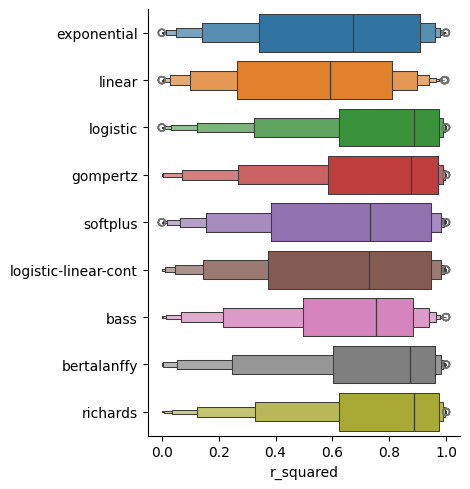

In [47]:
# distribution of r_squared

sns.catplot(y='functional_form', x='r_squared', hue='functional_form',
            data=fit_params[fit_params["r_squared"] > 0], kind='boxen', legend=False)
plt.ylabel('')


if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_dist.png', **savefig_settings)

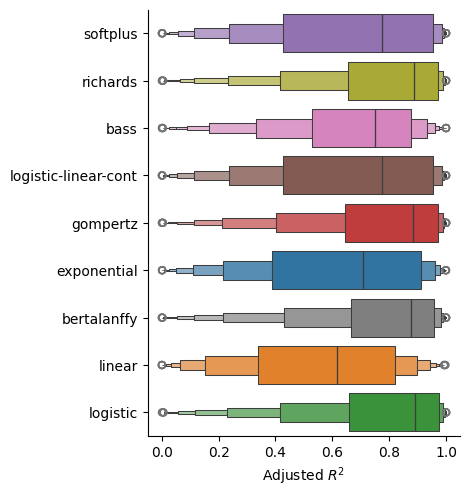

In [21]:
# distribution of MCp
sns.catplot(y='functional_form', x='adj_r_squared', hue='functional_form',
            data=fit_params[(fit_params["adj_r_squared"] > 0) & (fit_params["adj_r_squared"] <= 1)],
            kind='boxen', legend=False,
            order=['softplus', 'richards', 'bass', 'logistic-linear-cont', 'gompertz', 'exponential', 'bertalanffy', 'linear', 'logistic'])
plt.ylabel('')
plt.xlabel('Adjusted $R^2$')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_adj_r_squared_dist.png', **savefig_settings)

In [49]:
# distribution of MCp and BIC
# Note: these are dependent on the scale of the y data, therefore only useful to compare between models

fit_params['MCp'].quantile(q=[0.01, 0.1, 0.5, 0.9, 0.99])

0.01    1.129940e-08
0.10    1.182424e-03
0.50    4.405916e+02
0.90    9.497209e+09
0.99    1.436097e+13
Name: MCp, dtype: float64

In [50]:
fit_params['BIC'].quantile(q=[0.01, 0.1, 0.5, 0.9, 0.99])

0.01    1.249991e-08
0.10    1.316849e-03
0.50    4.855552e+02
0.90    1.041684e+10
0.99    1.623024e+13
Name: BIC, dtype: float64

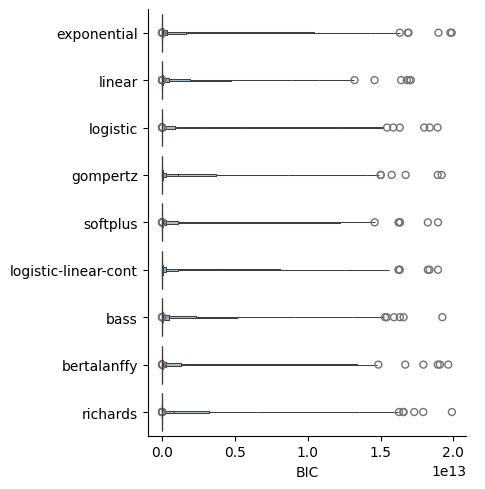

In [51]:
# distribution of BIC
sns.catplot(y='functional_form', x='BIC', data=fit_params[fit_params["BIC"] < 2e13], kind='boxen')
plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_bic_dist.png', **savefig_settings)

## Use BIC and MCp for ranking

In [14]:
fp_stats.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Technology Name_x', 'd', 'd_std', 'error_type',
       'error_msg', 'n', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name',
       'Technology Name_y'],
      dtype='object')

In [15]:
fp_stats['BIC_rank'] = fp_stats.groupby('technology')['BIC'].rank(method='min')
fp_stats['MCp_rank'] = fp_stats.groupby('technology')['MCp'].rank(method='min')
fp_stats['aRS_rank'] = fp_stats.groupby('technology')['adj_r_squared'].rank(method='min', ascending=False)
#fp_stats[['BIC', 'BIC_rank']]

# Calculate difference between adjusted r squared

In [16]:
good_fp_stats = fp_stats.loc[fp_stats['adj_r_squared'] > 0, :]

In [20]:
good_fp_stats['ar2_diff'] = np.nan
for t in fp_stats['technology']:
    good_fp_stats.loc[good_fp_stats['technology'] == t, 'ar2_diff'] = good_fp_stats.loc[good_fp_stats['technology'] == t, 'adj_r_squared'] - np.max(good_fp_stats.loc[good_fp_stats['technology'] == t, 'adj_r_squared'])

C:\Users\zacht\AppData\Local\Temp\ipykernel_106572\3965466038.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_fp_stats['ar2_diff'] = np.nan


In [21]:
good_fp_stats.loc[good_fp_stats['aRS_rank'] == 2, 'ar2_diff'].describe()

count    4.540000e+03
mean    -4.742392e-03
std      2.129521e-02
min     -9.579832e-01
25%     -3.711138e-03
50%     -9.273294e-04
75%     -1.234519e-04
max     -2.220446e-16
Name: ar2_diff, dtype: float64

In [15]:
best_ar2 = fp_stats.loc[fp_stats['aRS_rank'] == 1,]
bav = best_ar2['functional_form'].value_counts()
bav

functional_form
logistic                2386
linear                  1289
bertalanffy              536
exponential              515
gompertz                 486
logistic-linear-cont     239
bass                     163
richards                  95
softplus                  89
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_16724\614434766.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Adjusted R^2', bav[i], bottom = bottom, color = colorbar[i], alpha = 0.9)
C:\Users\zacht\AppData\Local\Temp\ipykernel_16724\614434766.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += bav[i]


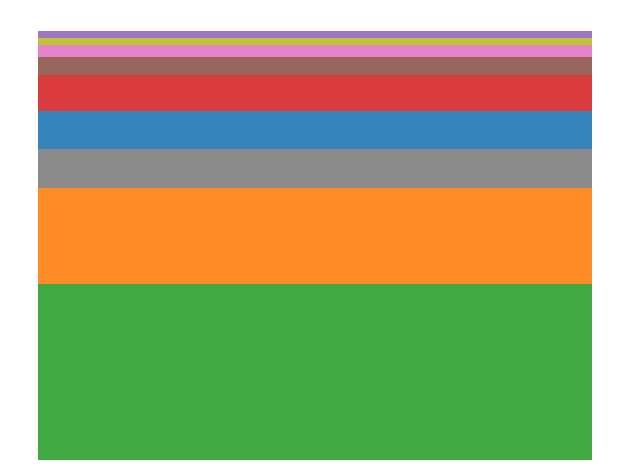

In [27]:
fig, ax = plt.subplots()

# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C2', 'C1', 'C7', 'C0', 'C3', 'C5', 'C6', 'C8', 'C4']
for i in range(0,len(bav)):
    ax.bar('Adjusted R^2', bav[i], bottom = bottom, color = colorbar[i], alpha = 0.9)
    bottom += bav[i]

ax.set_axis_off()
# ax.legend(loc = 'right')

plt.tight_layout()
plt.show()

In [28]:
best_bic = fp_stats.loc[fp_stats['BIC_rank'] == 1,]
biv = best_bic['functional_form'].value_counts()
biv

functional_form
logistic                2270
linear                  1452
bertalanffy              528
gompertz                 513
exponential              433
logistic-linear-cont     211
bass                      64
softplus                  51
richards                  37
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_16724\678670332.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('BIC', biv[i], bottom = bottom, color = colorbar[i], alpha = 0.9)
C:\Users\zacht\AppData\Local\Temp\ipykernel_16724\678670332.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += biv[i]


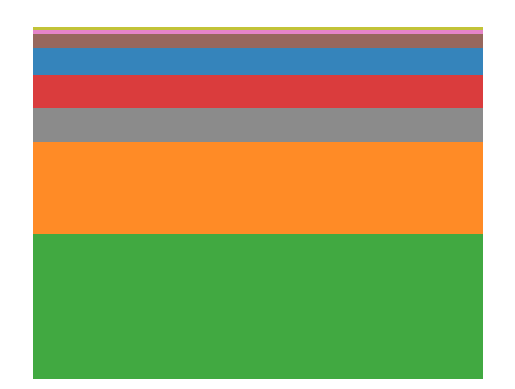

In [31]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C2', 'C1', 'C7', 'C3', 'C0', 'C5', 'C6', 'C8', 'C4']
for i in range(0,8):
    ax.bar('BIC', biv[i], bottom = bottom, color = colorbar[i], alpha = 0.9)
    bottom += biv[i]

ax.set_axis_off()

In [ ]:
best_both = best_ar2.merge(best_bic, on="technology")
best_both['same_best'] = best_both['functional_form_x'] == best_both['functional_form_y']
best_both['same_best'].value_counts()

same_best
True     4201
False     632
Name: count, dtype: int64

In [ ]:
mean_rank = fp_stats.groupby('functional_form')[['BIC_rank', 'MCp_rank', 'aRS_rank']].mean().sort_values(by='BIC_rank')
mean_rank.to_csv(f'results/{sample}_{day}_mean_bic_mcp_ars_rank.csv', float_format='%.2f')
mean_rank

,BIC_rank,MCp_rank,aRS_rank
functional_form,,,
logistic,2.753043,2.746723,2.757022
gompertz,3.547435,3.538065,3.541579
logistic-linear-cont,3.881788,3.879682,3.892322
softplus,4.417369,4.421114,4.463483
bertalanffy,4.469803,4.479635,4.496957
linear,5.148174,5.320693,5.420646
exponential,5.414560,5.416433,5.412219
richards,6.048379,5.863371,5.763955
bass,7.203092,7.118997,7.089248


In [ ]:
std_rank = fp_stats.groupby('functional_form')[['BIC_rank', 'MCp_rank', 'aRS_rank']].std().sort_values(by='BIC_rank')
std_rank.to_csv(f'results/{sample}_{day}_std_bic_mcp_ars_rank.csv', float_format='%.2f')
print("min:", std_rank.min().min())
print("max:", std_rank.max().max())

std_rank

min: 1.6165353134888945
max: 2.7564818971363256


,BIC_rank,MCp_rank,aRS_rank
functional_form,,,
gompertz,1.641126,1.643353,1.616535
logistic,1.715436,1.729081,1.712621
softplus,1.939100,1.950850,2.061553
bass,1.968872,2.020927,2.195235
logistic-linear-cont,1.974159,1.987823,1.984154
richards,1.989219,2.019010,2.095248
bertalanffy,2.090772,2.090246,2.099475
linear,2.403846,2.379509,2.384909
exponential,2.642447,2.658072,2.756482


## Compare parameters from different functional forms

Text(0, 0.5, 'softplus')

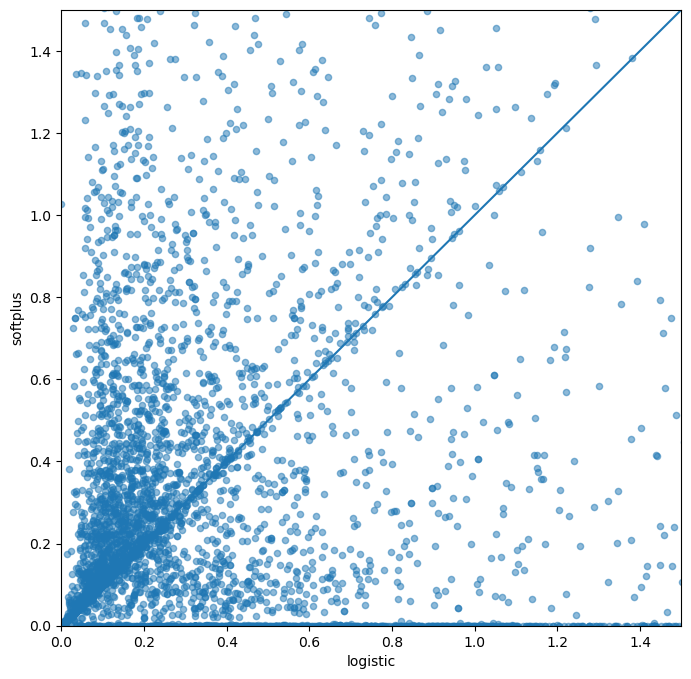

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

type_x = "logistic"
type_y = "softplus"

merged_df = fit_params[fit_params["functional_form"] == type_x].merge(fit_params[fit_params["functional_form"] == type_y], on="technology")
merged_df.plot.scatter(x="b_x", y="b_y", ax=ax, alpha=0.5)
xy_max = 1.5
ax.plot([0, xy_max], [0, xy_max])
ax.set_ylim([0, xy_max])
ax.set_xlim([0, xy_max])
ax.set_xlabel(type_x)
ax.set_ylabel(type_y)

Text(0, 0.5, 'exponential')

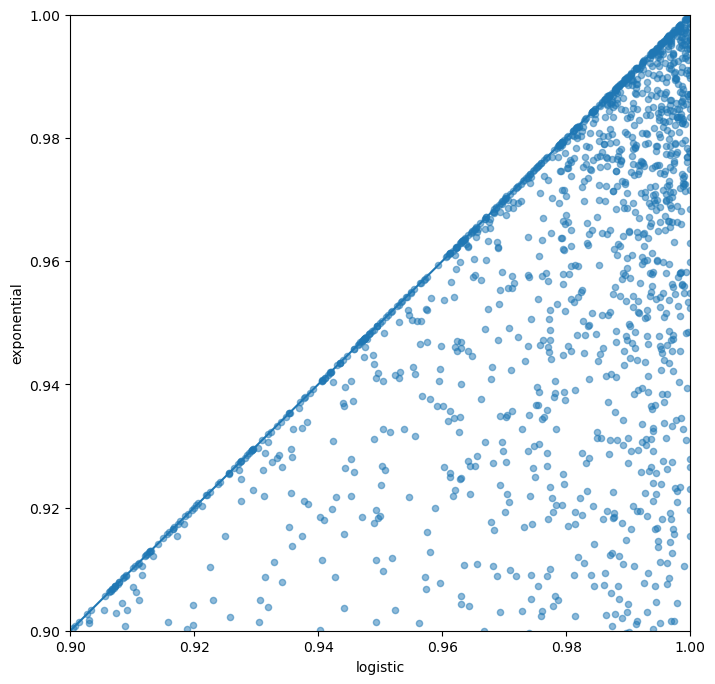

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

type_x = "logistic"
type_y = "exponential"

merged_df = fit_params[fit_params["functional_form"] == type_x].merge(fit_params[fit_params["functional_form"] == type_y], on="technology")
merged_df.plot.scatter(x="r_squared_x", y="r_squared_y", ax=ax, alpha=0.5)
xy_min = 0.9
ax.plot([xy_min, 1], [xy_min, 1])
ax.set_ylim([xy_min, 1])
ax.set_xlim([xy_min, 1])
ax.set_xlabel(type_x)
ax.set_ylabel(type_y)

## Augment fit parameter data with categories from dataset

In [1]:
hatch = read_hatch.read_hatch('data/HATCH_v1.5_clean.csv')

meta_data_cols = hatch.columns[:8]
meta_data_cols

NameError: name 'read_hatch' is not defined

In [ ]:
print(len(hatch))
print(pd.isna(hatch.iloc[0,8]))
(len(hatch)*len(hatch.iloc[0,8:])) - sum(pd.isna(hatch.iloc[:,8:]))


5547
True


1201147

In [ ]:
fp_aug = pd.merge(fit_params[fit_params['r_squared'] > 0], hatch[meta_data_cols], left_on='technology', right_index=True, how="left", )
fp_aug.head()

,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,error_type,error_msg,Spatial Scale,Region,Country Name,Technology Name,Metric,Unit,Data Source,Variable
0,exponential,curve_fit,True,0.487690,0.481543,7392.699074,7694.435010,1.000000,100.391781,0.010812,...,NaN,NaN,National,JAM,Jamaica,Cane Sugar,Annual Production,thousand metric tons,Mitchell,Annual Production|Cane Sugar
1,linear,curve_fit,True,0.406591,0.401862,8497.110214,8730.111137,1.900888,-1800.686448,1.014233,...,NaN,NaN,National,JAM,Jamaica,Cane Sugar,Annual Production,thousand metric tons,Mitchell,Annual Production|Cane Sugar
2,logistic,curve_fit,True,0.706834,0.703316,4230.427951,4403.094541,1.000000,289.208416,0.201153,...,NaN,NaN,National,JAM,Jamaica,Cane Sugar,Annual Production,thousand metric tons,Mitchell,Annual Production|Cane Sugar
3,gompertz,curve_fit,True,0.699004,0.695392,4343.411429,4520.689483,1.000000,287.769584,0.171707,...,NaN,NaN,National,JAM,Jamaica,Cane Sugar,Annual Production,thousand metric tons,Mitchell,Annual Production|Cane Sugar
4,softplus,curve_fit,True,0.513636,0.507799,7018.305734,7304.760657,1.000000,2.500417,0.090887,...,NaN,NaN,National,JAM,Jamaica,Cane Sugar,Annual Production,thousand metric tons,Mitchell,Annual Production|Cane Sugar


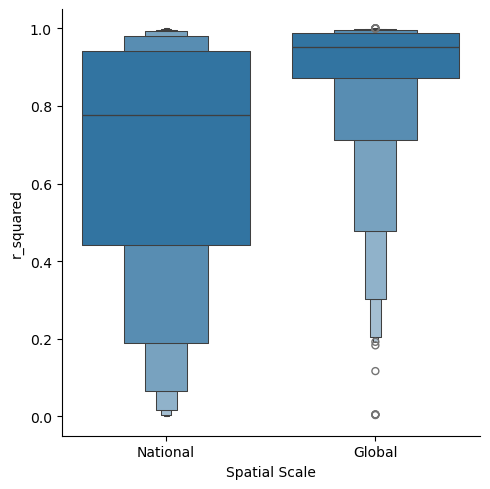

In [ ]:
sns.catplot(x='Spatial Scale', y='r_squared', data=fp_aug, kind='boxen')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_by_spatial_scale.png', **savefig_settings)

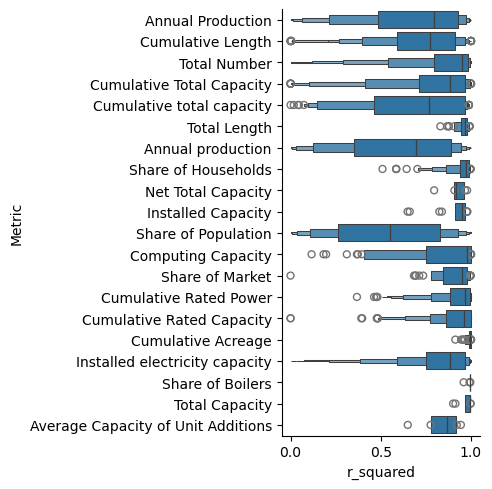

In [ ]:
sns.catplot(y='Metric', x='r_squared', data=fp_aug, kind='boxen')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_r_squared_by_metric.png', **savefig_settings)

# Read hindcasting results

In [ ]:
hindcast = pd.read_csv(f"./results/hindcasting_results_all_2024-10-22.csv", index_col=[0])
print(len(hindcast))
hindcast.columns



38448


Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Length_test', 'Hindcast_MAPE', 'd', 'd_std',
       'error_type', 'error_msg'],
      dtype='object')

In [ ]:
hindcast['Hindcast_MAPE'].quantile([0.5, 0.9, 0.95, 0.99])


0.50         0.337610
0.90        10.998461
0.95       246.562827
0.99    123731.417305
Name: Hindcast_MAPE, dtype: float64

# Plot hindcasting MAPE

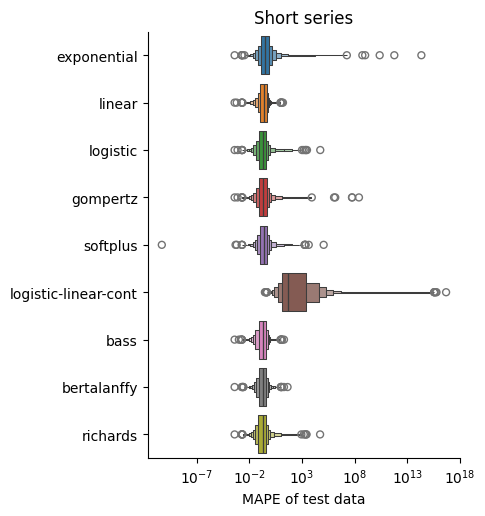

In [ ]:
sns.catplot(y='functional_form', x='Hindcast_MAPE', hue='functional_form',
            data=hindcast[(hindcast['Hindcast_MAPE'] > 0) & (hindcast['Length_test'] < 20)], #(hindcast['Hindcast_MAPE'] < 10^9) & 
            kind='boxen', legend=False)
plt.ylabel('')
plt.xlabel('MAPE of test data')
plt.xscale('log')
plt.title('Short series')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_hindcast_short.png', **savefig_settings)

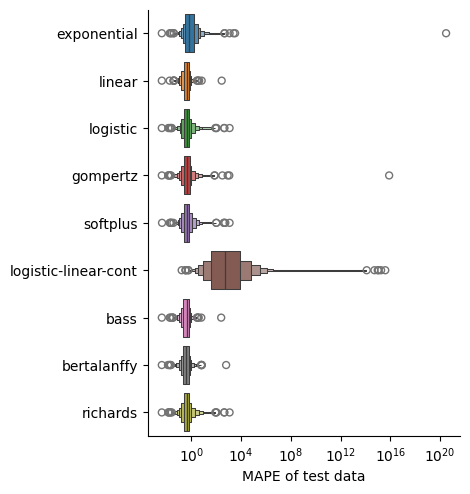

In [ ]:
sns.catplot(y='functional_form', x='Hindcast_MAPE', hue='functional_form',
            data=hindcast[(hindcast['Hindcast_MAPE'] > 0) & (hindcast['Length_test'] >= 20)], #(hindcast['Hindcasting'] < 10^9) & 
            kind='boxen', legend=False)
plt.ylabel('')
plt.xlabel('MAPE of test data')
plt.xscale('log')
# plt.title('Long series')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_hindcast_long.png', **savefig_settings)

# Plot testing MAPE

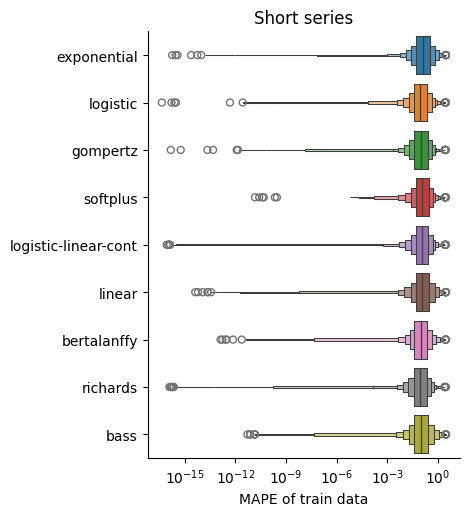

In [ ]:
sns.catplot(y='functional_form', x='MAPE', hue='functional_form',
            data=hindcast[(hindcast['MAPE'] < 10^9) & (hindcast['MAPE'] > 0) & (hindcast['Length_test'] < 20)], 
            kind='boxen', legend=False)
plt.ylabel('')
plt.xlabel('MAPE of test data')
plt.xscale('log')
plt.title('Short series')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_testmape_short.png', **savefig_settings)

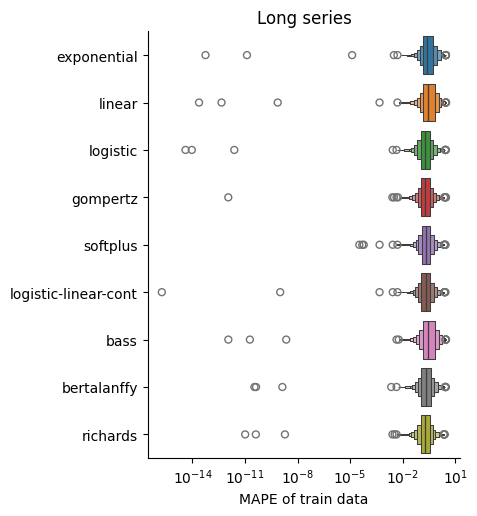

In [ ]:
sns.catplot(y='functional_form', x='MAPE', hue='functional_form',
            data=hindcast[(hindcast['MAPE'] < 10^9) & (hindcast['MAPE'] > 0) & (hindcast['Length_test'] >= 20)], 
            kind='boxen', legend=False)
plt.ylabel('')
plt.xlabel('MAPE of test data')
plt.xscale('log')
plt.title('Long series')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_testmape_long.png', **savefig_settings)

# Scatter plots of hindcasting for length of data

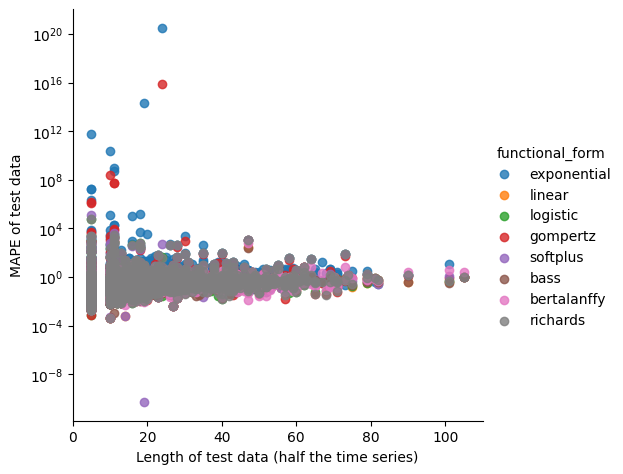

In [ ]:
sns.lmplot(x = 'Length_test', y = 'Hindcast_MAPE', data = hindcast[hindcast['functional_form'] != "logistic-linear-cont"], hue = 'functional_form', fit_reg=False)
plt.yscale('log')
plt.ylabel('MAPE of test data')
plt.xlabel('Length of test data (half the time series)')

save_fig=True

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_MAPEvLength.png', **savefig_settings)

# Read continuous hindcast data

In [2]:
# conthind = pd.read_csv(f"./results/conthind_results_all_2024-11-17.csv", index_col=0)
conthind = pd.read_parquet("./results/conthind_results_all_2025-10-26.parquet")
print(len(conthind))
conthind.columns

5015610


Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flag', 'technology', 'Start_index',
       'Length_train', 'Length_test', 'Hindcast_MAPE', 'outside_CI', 'CI_size',
       'd', 'd_std', 'error_type', 'error_msg'],
      dtype='object')

In [3]:
def sigmoid(x):
    try:
        return (1+np.exp(-1))/(1+np.exp(-x))
    except Exception as error:
        return np.nan
conthind['sigmoid_r2'] = sigmoid(conthind['adj_r_squared'])
conthind['log_test_MAPE'] = np.log10(conthind['Hindcast_MAPE'])
conthind.loc[conthind['log_test_MAPE'] <= -20, 'log_test_MAPE'] = -20
conthind['ar20'] = conthind['adj_r_squared']
conthind.loc[conthind['ar20'] < 0, 'ar20'] = np.nan
conthind['ar2_rank'] = conthind.groupby('technology')['adj_r_squared'].rank(method='min', ascending=False)
conthind['bestlog'] = (conthind['ar2_rank'] == 1) & (conthind['functional_form'] == 'logistic')
conthind.loc[conthind['adj_r_squared'] >= 0.5, 'adj_r2_bin'] = '>0.5'
conthind.loc[conthind['adj_r_squared'] >= 0.8, 'adj_r2_bin'] = '>0.8'
conthind.loc[conthind['adj_r_squared'] >= 0.95, 'adj_r2_bin'] = '>0.95'
conthind.loc[conthind['adj_r_squared'] < 0.5, 'adj_r2_bin'] = '<0.5'
conthind['adj_r2_bin'].value_counts()
conthind['Hindcast_MAPE'] = conthind['Hindcast_MAPE']*100


C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
metadata = pd.read_csv("./data/full_table_of_predictors_all.csv", index_col=0)
entechlist = metadata.loc[metadata['Category Type'] == 'Energy Supply', 'technology'].unique()
entechlist

array(['Crude Petroleum_Annual Production_US',
       'Crude Petroleum_Annual Production_CA',
       'Crude Petroleum_Annual Production_JP', ...,
       'Marine Energy_Installed electricity capacity_BR',
       'Solar Photovoltaic_Installed electricity capacity_LV',
       'Solar Photovoltaic_Installed electricity capacity_AI'],
      dtype=object)

In [5]:
print(conthind.shape)
# print(conthind_cat.shape)

(6970590, 31)


# Which function is best for MAPE

In [4]:
conthind['fitindex'] = conthind['technology'] + conthind['Length_test'].astype(str) + 't' + conthind['Length_train'].astype(str) + 'n' + conthind['Start_index'].astype(str) + 's'
conthind['MAPE_rank'] = conthind.groupby('fitindex')['log_test_MAPE'].rank(method='min')
conthind['ar2_rank'] = conthind.groupby('fitindex')['adj_r_squared'].rank(method='min', ascending=False)

conthind['add_score'] = conthind['ar2_rank'] + conthind['MAPE_rank']
conthind['add_rank'] = conthind.groupby('fitindex')['add_score'].rank(method = 'min')

conthind['saturates'] = conthind['functional_form'].isin(['logistic', 'bass', 'gompertz', 'bertalanffy', 'richards'])
conthind['familyindex'] = conthind['technology'] + conthind['functional_form'] + conthind['Start_index'].astype(str) + 's'
family_list = list(dict.fromkeys(conthind.loc[conthind['adj_r_squared'] < 0.95, 'familyindex']))
family8_list = list(dict.fromkeys(conthind.loc[conthind['adj_r_squared'] < 0.8, 'familyindex']))
family5_list = list(dict.fromkeys(conthind.loc[conthind['adj_r_squared'] < 0.5, 'familyindex']))
family0_list = list(dict.fromkeys(conthind.loc[conthind['adj_r_squared'] < 0, 'familyindex']))

conthind['maxlength'] = conthind['Length_test'] + conthind['Length_train']
technology_list = list(dict.fromkeys(conthind.loc[conthind['maxlength'] > 40, 'technology']))
technology20_list = list(dict.fromkeys(conthind.loc[conthind['maxlength'] > 15, 'technology']))

In [63]:
cont_ar2 = conthind.loc[conthind['ar2_rank'] == 1,]
cav = cont_ar2['functional_form'].value_counts()
cav

functional_form
linear                  208435
logistic                200606
exponential             130152
bertalanffy             125170
logistic-linear-cont     63543
gompertz                 57840
softplus                 41149
bass                     27998
richards                 20291
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_872\2031430457.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Adjusted R^2', cav[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_872\2031430457.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cav[i]


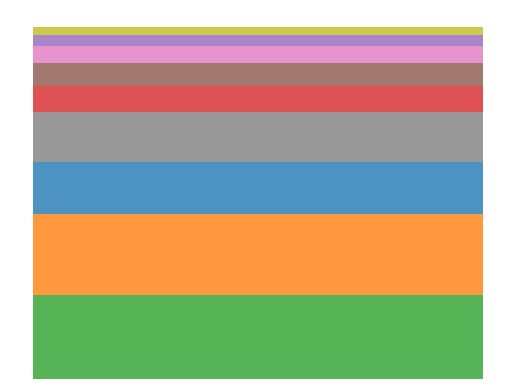

In [64]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C2', 'C1', 'C0', 'C7', 'C3', 'C5', 'C6', 'C4', 'C8']
for i in range(0,len(cav)):
    ax.bar('Adjusted R^2', cav[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cav[i]

ax.set_axis_off()

In [65]:
cont_mape = conthind.loc[conthind['MAPE_rank'] == 1,]
cmv = cont_mape['functional_form'].value_counts()
cmv

functional_form
exponential             155902
bertalanffy             126525
bass                    122378
softplus                109415
linear                   87586
logistic                 69260
gompertz                 53605
richards                 49382
logistic-linear-cont       947
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\1666326467.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmv[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\1666326467.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmv[i]


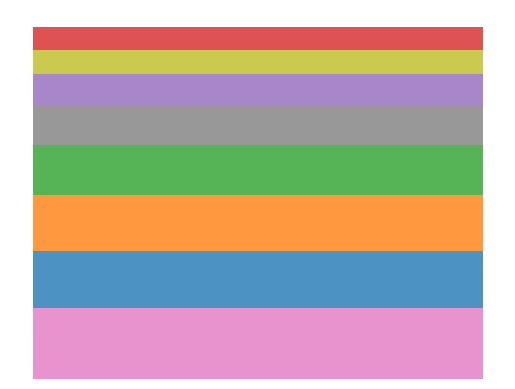

In [15]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C0', 'C1', 'C2', 'C7', 'C4', 'C8', 'C3', 'C5']
for i in range(0,len(cmv)):
    ax.bar('Average % error', cmv[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmv[i]

ax.set_axis_off()

In [16]:
cont_mape_early = conthind.loc[(conthind['MAPE_rank'] == 1) & (conthind['Start_index'] < 10),]
cmve = cont_mape_early['functional_form'].value_counts()
cmve

functional_form
softplus                50668
bertalanffy             47990
bass                    41692
exponential             38872
linear                  24528
logistic                22938
richards                16942
gompertz                16347
logistic-linear-cont      431
Name: count, dtype: int64

In [17]:
tech_list = cont_mape_early.loc[(cont_mape_early['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

np.float64(0.2828823120921478)

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\2228980448.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmve[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\2228980448.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmve[i]


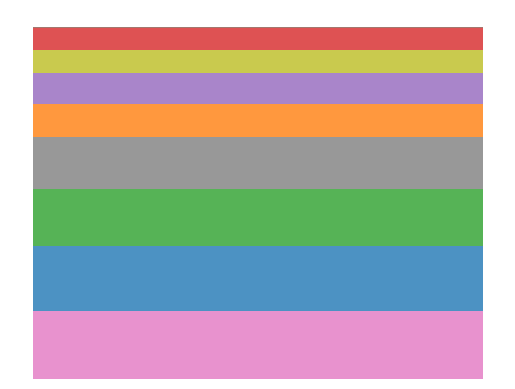

In [18]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C0', 'C2', 'C7', 'C1', 'C4', 'C8', 'C3', 'C5']
for i in range(0,len(cmve)):
    ax.bar('Average % error', cmve[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmve[i]

ax.set_axis_off()

In [ ]:
cont_mape_esf = conthind.loc[(conthind['MAPE_rank'] == 1) & (conthind['Start_index'] < 10) & ((conthind['Length_train'] > 25) & (conthind['Length_test'] > 25)),]
cmvesf = cont_mape_esf['functional_form'].value_counts()
cmvesf

functional_form
bertalanffy             1677
softplus                1524
exponential             1333
gompertz                 670
linear                   575
bass                     534
logistic                 490
richards                 332
logistic-linear-cont       8
Name: count, dtype: int64

In [20]:
tech_list = cont_mape_esf.loc[(cont_mape_esf['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])


np.float64(0.4107582406370337)

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\1063831418.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmvesf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\1063831418.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmvesf[i]


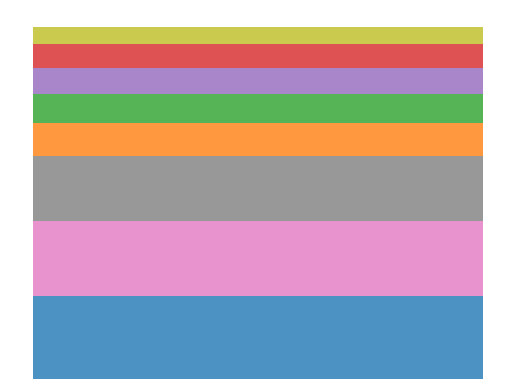

In [21]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C0', 'C6', 'C7', 'C1', 'C2', 'C4', 'C3', 'C8', 'C5']
for i in range(0,len(cmvesf)):
    ax.bar('Average % error', cmvesf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmvesf[i]

ax.set_axis_off()

In [ ]:
cont_mape_esc = conthind.loc[(conthind['MAPE_rank'] == 1) & (conthind['Start_index'] < 10) & (conthind['Length_train'] > 25) & (conthind['Length_test'] < 10),]
cmvesc = cont_mape_esc['functional_form'].value_counts()
cmvesc

functional_form
bertalanffy             3783
exponential             3086
bass                    2883
logistic                2779
softplus                2276
richards                1951
gompertz                1599
linear                  1316
logistic-linear-cont       5
Name: count, dtype: int64

In [23]:
tech_list = cont_mape_esc.loc[(cont_mape_esc['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

np.float64(0.13569641329545995)

NameError: name 'cmves' is not defined

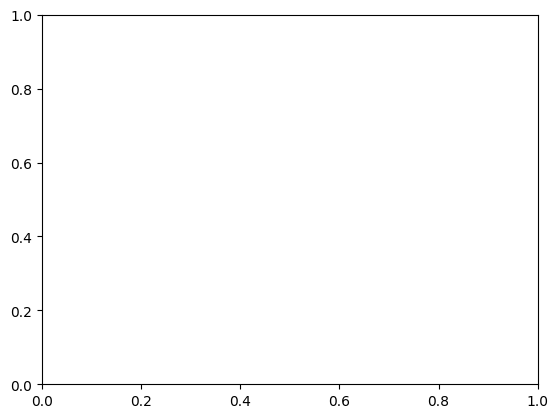

In [24]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C2', 'C0', 'C7', 'C8', 'C1', 'C3', 'C4', 'C5']
for i in range(0,len(cmves)):
    ax.bar('Average % error', cmves[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmves[i]

ax.set_axis_off()

In [ ]:
cont_mape_lsc = conthind.loc[(conthind['MAPE_rank'] == 1) & ((conthind['Start_index'] > 30)) & ((conthind['Length_train'] < 10)) & (conthind['Length_test'] < 10),]
cmvlsc = cont_mape_lsc['functional_form'].value_counts()
cmvlsc

functional_form
exponential             5235
bass                    3309
linear                  2379
softplus                1450
bertalanffy             1387
gompertz                1354
logistic                1353
richards                 757
logistic-linear-cont       6
Name: count, dtype: int64

In [9]:
tech_list = cont_mape_lsc.loc[(cont_mape_lsc['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

NameError: name 'cont_mape_lsc' is not defined

C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\3797652635.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmvlsc[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\3797652635.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmvlsc[i]


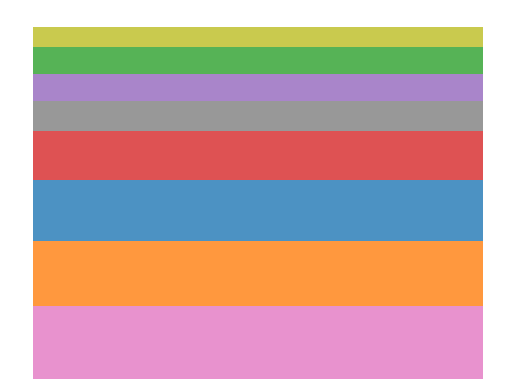

In [53]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C1', 'C0', 'C3', 'C7', 'C4', 'C2', 'C8', 'C5']
for i in range(0,len(cmvlsc)):
    ax.bar('Average % error', cmvlsc[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmvlsc[i]

ax.set_axis_off()

In [ ]:
cont_mape_lsf = conthind.loc[(conthind['MAPE_rank'] == 1) & ((conthind['Start_index'] > 30)) & ((conthind['Length_train'] < 10)) & (conthind['Length_test'] > 25),]
cmvlsf = cont_mape_lsf['functional_form'].value_counts()
cmvlsf

functional_form
bass                    1197
linear                   649
exponential              617
softplus                 578
bertalanffy              452
logistic                 290
richards                 243
gompertz                 240
logistic-linear-cont      18
Name: count, dtype: int64

In [129]:
tech_list = cont_mape_lsf.loc[(cont_mape_lsf['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

np.float64(0.2947029875708141)

C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\1848244800.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmvlsf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\1848244800.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmvlsf[i]


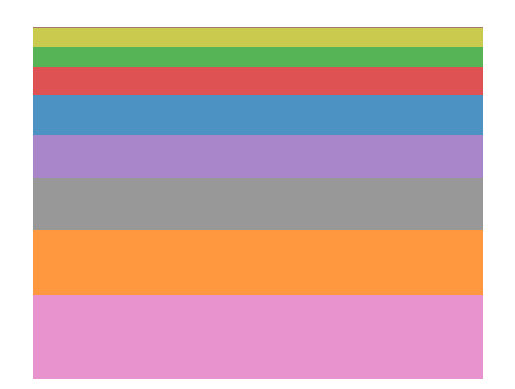

In [55]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C1', 'C7', 'C4', 'C0', 'C3', 'C2', 'C8', 'C5']
for i in range(0,len(cmvlsf)):
    ax.bar('Average % error', cmvlsf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmvlsf[i]

ax.set_axis_off()

In [ ]:
cont_mape_elc = conthind.loc[(conthind['MAPE_rank'] == 1) & ((conthind['Start_index'] < 10)) & ((conthind['Length_train'] > 25)) & (conthind['Length_test'] < 10),]
cmvelc = cont_mape_elc['functional_form'].value_counts()
cmvelc

functional_form
bertalanffy             3783
exponential             3086
bass                    2883
logistic                2779
softplus                2276
richards                1951
gompertz                1599
linear                  1316
logistic-linear-cont       5
Name: count, dtype: int64

In [28]:
tech_list = cont_mape_elc.loc[(cont_mape_elc['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

np.float64(0.13569641329545995)

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\481232840.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmvelc[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\481232840.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmvelc[i]


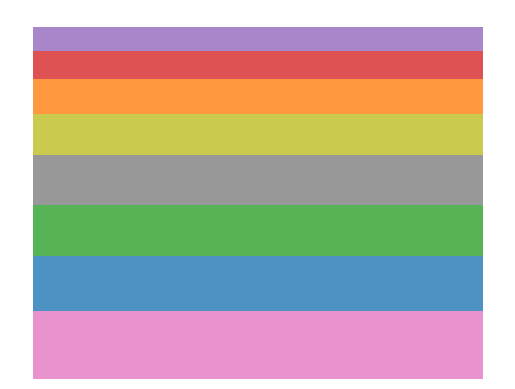

In [29]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C6', 'C0', 'C2', 'C7', 'C8', 'C1', 'C3', 'C4', 'C5']
for i in range(0,len(cmvelc)):
    ax.bar('Average % error', cmvelc[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmvelc[i]

ax.set_axis_off()

In [ ]:
cont_mape_elf = conthind.loc[(conthind['MAPE_rank'] == 1) & ((conthind['Start_index'] < 10)) & ((conthind['Length_train'] > 25)) & (conthind['Length_test'] > 25),]
cmvelf = cont_mape_elf['functional_form'].value_counts()
cmvelf

functional_form
bertalanffy             1677
softplus                1524
exponential             1333
gompertz                 670
linear                   575
bass                     534
logistic                 490
richards                 332
logistic-linear-cont       8
Name: count, dtype: int64

In [31]:
tech_list = cont_mape_elf.loc[(cont_mape_elf['functional_form'] == "exponential"), 'fitindex']
np.mean(conthind.loc[(conthind['MAPE_rank'] > 1) & (conthind['MAPE_rank'] < 3) & (conthind['fitindex'].isin(tech_list)), 'Hindcast_MAPE'])

np.float64(0.4107582406370337)

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\3430587761.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cmvelf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\3430587761.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cmvelf[i]


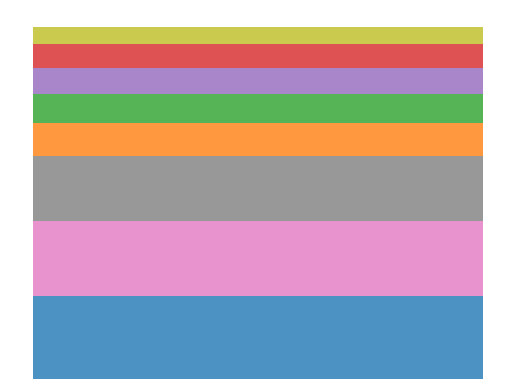

In [32]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C0', 'C6', 'C7', 'C1', 'C2', 'C4', 'C3', 'C8', 'C5']
for i in range(0,len(cmvelf)):
    ax.bar('Average % error', cmvelf[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cmvelf[i]

ax.set_axis_off()

In [33]:
cont_add = conthind.loc[conthind['add_rank'] == 1,]
cba = cont_add['functional_form'].value_counts()
cba

functional_form
logistic                250151
bertalanffy             179557
linear                  164616
gompertz                157886
softplus                147116
exponential             135214
richards                 45493
bass                     30281
logistic-linear-cont       863
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\3017290785.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Average % error', cba[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_37108\3017290785.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cba[i]


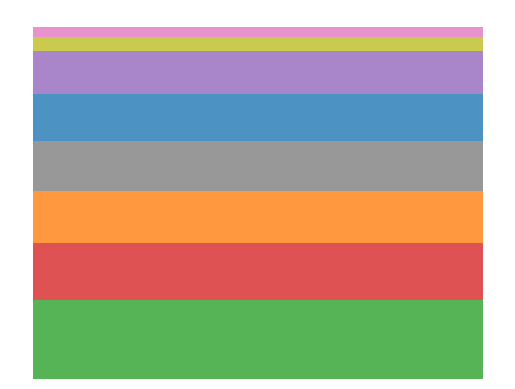

In [34]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C2', 'C3', 'C1', 'C7', 'C0', 'C4', 'C8', 'C6', 'C5']
for i in range(0,len(cba)):
    ax.bar('Average % error', cba[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cba[i]

ax.set_axis_off()

In [35]:
cont_ar2_funcfit = cont_ar2[['functional_form', 'fitindex']]
cont_mape_funcfit = cont_mape[['functional_form', 'fitindex']]
cont_both = cont_ar2_funcfit.merge(cont_mape_funcfit, on="fitindex")
cont_both['same_best'] = cont_both['functional_form_x'] == cont_both['functional_form_y']
cont_both['same_best'].value_counts()

same_best
False    703603
True     174911
Name: count, dtype: int64

In [11]:
cont_both.columns

NameError: name 'cont_both' is not defined

In [10]:
best_ar2_for_mape = cont_both['functional_form_x'].value_counts()
best_ar2_for_mape

NameError: name 'cont_both' is not defined

In [65]:
best_mape_for_ar2 = cont_both['functional_form_y'].value_counts()
best_mape_for_ar2

functional_form_y
bass                    63482
exponential             48830
linear                  41310
bertalanffy             35249
logistic                35102
softplus                33223
gompertz                30551
richards                25498
logistic-linear-cont     1760
Name: count, dtype: int64

In [ ]:
# for func in plotdata['adj_r2_bin'].unique():
#     ich = plotdata[plotdata['adj_r2_bin'] == func]
#     medch = ich.groupby(['Length_train', 'Length_test'], as_index=False)['log_test_MAPE'].std()
#     fullcross = pd.DataFrame([(x,y) for x in range(25) for y in range(25)], columns=['Length_train', 'Length_test'])
#     phc = pd.merge(left = fullcross, right = medch, how = 'left')

#     x = np.arange(25)
#     y = np.arange(25)
#     z = np.array(np.log(phc['log_test_MAPE']))
#     z = z.reshape(len(x), len(y))
#     X,Y = np.meshgrid(x,y)

#     fig, ax = plt.subplots(figsize=(8,8))
#     CS = ax.contourf(X,Y,z, cmap = "Reds")
#     CB = fig.colorbar(CS)
#     plt.title(func)
#     plt.xlabel('Length of test data')
#     plt.ylabel('Length of train data')

#     # if save_fig:
#     #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)



# #cs = ax.contour('Length_train', 'Length_test', 'Hindcast_MAPE', data=phc)

# #medch.plot.scatter(x='Length_test',y='Length_train',ax=ax, c='Hindcast_MAPE', cmap='Blues')



In [12]:
cont_ma = conthind.loc[(conthind['MAPE_rank'] == 1) & (conthind['ar2_rank'] == 1),]
cbv = cont_ma['functional_form'].value_counts()
cbv

functional_form
exponential             43958
linear                  37265
bertalanffy             32745
logistic                30356
softplus                16366
gompertz                 6749
bass                     5412
richards                 1941
logistic-linear-cont      119
Name: count, dtype: int64

C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\1759297611.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.bar('Adjusted R^2', cav[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
C:\Users\zacht\AppData\Local\Temp\ipykernel_2532\1759297611.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom += cav[i]


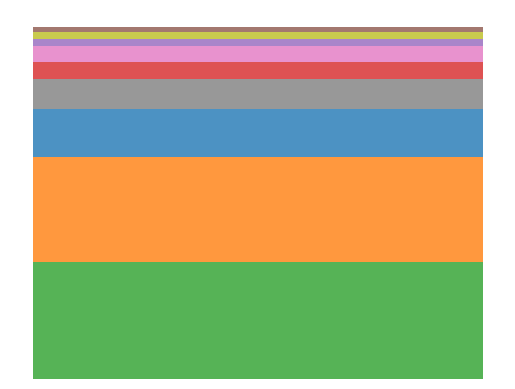

In [68]:
fig, ax = plt.subplots()
# ax.pie(bav, labels = bav.index)

bottom = 0
colorbar = ['C2', 'C1', 'C0', 'C7', 'C3', 'C6', 'C4', 'C8', 'C5']
for i in range(0,len(cav)):
    ax.bar('Adjusted R^2', cav[i], bottom = bottom, color = colorbar[i], alpha = 0.8)
    bottom += cav[i]

ax.set_axis_off()

# Various scatterplots

## SI r2

In [5]:
plotdata = conthind.loc[(conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['logistic', 'linear', 'exponential', 'softplus'])), ['Hindcast_MAPE', 'ar20', 'functional_form', 'technology']].dropna()
# & (conthind['MAPE_rank'] == 1) 
# (conthind['ar2_rank'] == 1) & 
# (conthind['ar20'] < 1) & 

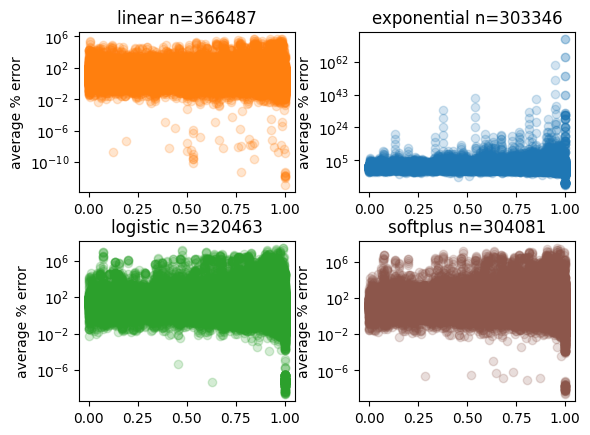

In [6]:
fig, axs = plt.subplots(2,2)
plt.subplots_adjust(wspace=0.3, hspace=0.3)

axs[0,0].scatter(plotdata.loc[plotdata['functional_form'] == 'linear', 'ar20'], plotdata.loc[plotdata['functional_form'] == 'linear', 'Hindcast_MAPE'], c = 'C1', alpha = 0.2)
axs[0,1].scatter(plotdata.loc[plotdata['functional_form'] == 'exponential', 'ar20'], plotdata.loc[plotdata['functional_form'] == 'exponential', 'Hindcast_MAPE'], c = 'C0', alpha = 0.2)
axs[1,0].scatter(plotdata.loc[plotdata['functional_form'] == 'logistic', 'ar20'], plotdata.loc[plotdata['functional_form'] == 'logistic', 'Hindcast_MAPE'], c = 'C2', alpha = 0.2)
axs[1,1].scatter(plotdata.loc[plotdata['functional_form'] == 'softplus', 'ar20'], plotdata.loc[plotdata['functional_form'] == 'softplus', 'Hindcast_MAPE'], c = 'C5', alpha = 0.2)

axs[0,0].set_title('linear n='+str(len(plotdata.loc[plotdata['functional_form'] == 'linear', 'ar20'])))
axs[0,1].set_title('exponential n='+str(len(plotdata.loc[plotdata['functional_form'] == 'exponential', 'ar20'])))
axs[1,0].set_title('logistic n='+str(len(plotdata.loc[plotdata['functional_form'] == 'logistic', 'ar20'])))
axs[1,1].set_title('softplus n='+str(len(plotdata.loc[plotdata['functional_form'] == 'softplus', 'ar20'])))

axs[0,0].set_ylabel('average % error')
axs[0,1].set_ylabel('average % error')
axs[1,0].set_ylabel('average % error')
axs[1,1].set_ylabel('average % error')

axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[1,0].set_yscale('log')
axs[1,1].set_yscale('log')

plt.show()

In [68]:
plotdata = conthind.loc[(conthind['ar20'] < 1) & (conthind['ar2_rank'] == 1) & (conthind['MAPE_rank'] == 1) & (conthind['functional_form'].isin(['logistic', 'linear', 'exponential', 'bass'])), ['Hindcast_MAPE', 'Length_test', 'functional_form', 'technology']].dropna()

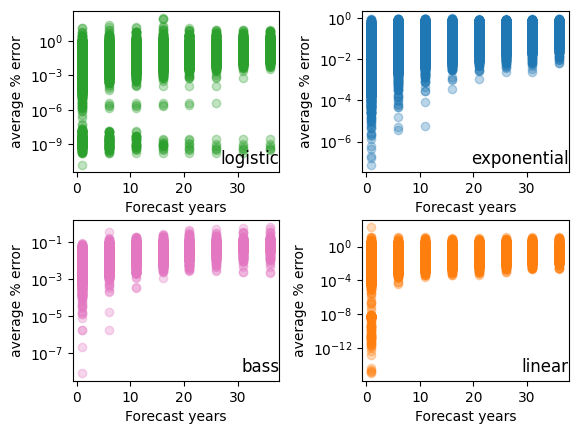

In [69]:
fig, axs = plt.subplots(2,2)
plt.subplots_adjust(wspace=0.4, hspace=0.3)

axs[0,0].scatter(plotdata.loc[plotdata['functional_form'] == 'logistic', 'Length_test'], plotdata.loc[plotdata['functional_form'] == 'logistic', 'Hindcast_MAPE'], c = 'C2', alpha = 0.3)
axs[0,1].scatter(plotdata.loc[plotdata['functional_form'] == 'exponential', 'Length_test'], plotdata.loc[plotdata['functional_form'] == 'exponential', 'Hindcast_MAPE'], c = 'C0', alpha = 0.3)
axs[1,0].scatter(plotdata.loc[plotdata['functional_form'] == 'bass', 'Length_test'], plotdata.loc[plotdata['functional_form'] == 'bass', 'Hindcast_MAPE'], c = 'C6', alpha = 0.3)
axs[1,1].scatter(plotdata.loc[plotdata['functional_form'] == 'linear', 'Length_test'], plotdata.loc[plotdata['functional_form'] == 'linear', 'Hindcast_MAPE'], c = 'C1', alpha = 0.3)

axs[0,0].set_title('logistic', y = 0, loc = 'right')
axs[0,1].set_title('exponential', y = 0, loc = 'right')
axs[1,0].set_title('bass', y = 0, loc = 'right')
axs[1,1].set_title('linear', y = 0, loc = 'right')

axs[0,0].set_ylabel('average % error')
axs[0,1].set_ylabel('average % error')
axs[1,0].set_ylabel('average % error')
axs[1,1].set_ylabel('average % error')


axs[0,0].set_xlabel('Forecast years')
axs[0,1].set_xlabel('Forecast years')
axs[1,0].set_xlabel('Forecast years')
axs[1,1].set_xlabel('Forecast years')

axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[1,0].set_yscale('log')
axs[1,1].set_yscale('log')

plt.show()

In [66]:
conthind.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flag', 'technology', 'Start_index',
       'Length_train', 'Length_test', 'Hindcast_MAPE', 'd', 'd_std',
       'error_type', 'error_msg', 'sigmoid_r2', 'log_test_MAPE', 'ar20',
       'ar2_rank', 'bestlog', 'adj_r2_bin', 'fitindex', 'MAPE_rank',
       'add_score', 'add_rank', 'saturates', 'bestexp', 'bestlin', 'bestbass'],
      dtype='object')

In [17]:
log_perc = conthind.loc[conthind['functional_form'] == 'logistic', 'Hindcast_MAPE'].quantile(q=[0.001, 0.999])
exp_perc = conthind.loc[conthind['functional_form'] == 'exponential', 'Hindcast_MAPE'].quantile(q=[0.001, 0.999])
lin_perc = conthind.loc[conthind['functional_form'] == 'linear', 'Hindcast_MAPE'].quantile(q=[0.001, 0.999])

out_lin_tech = conthind.loc[(conthind['Hindcast_MAPE'] < lin_perc.iloc[0]) | (conthind['Hindcast_MAPE'] > lin_perc.iloc[1]), 'technology'].unique()
out_exp_tech = conthind.loc[(conthind['Hindcast_MAPE'] < exp_perc.iloc[0]) | (conthind['Hindcast_MAPE'] > exp_perc.iloc[1]), 'technology'].unique()
out_log_tech = conthind.loc[(conthind['Hindcast_MAPE'] < log_perc.iloc[0]) | (conthind['Hindcast_MAPE'] > log_perc.iloc[1]), 'technology'].unique()


In [18]:
out_tech = list(set(out_lin_tech.tolist() + out_exp_tech.tolist() + out_log_tech.tolist()))


In [19]:
plotdata = conthind.loc[(conthind['ar20'] > 0.9) & (conthind['ar20'] < 0.9999) & (conthind['ar2_rank'] == 1), ['Hindcast_MAPE', 'ar20', 'Length_test', 'Length_train', 'saturates', 'technology']].dropna()
# & (conthind['Hindcast_MAPE'] < 1000000)

In [7]:
train0 = 6
train1 = 21
train2 = 36

test1 = 6
test1 = 21
test2 = 36

In [21]:
medsatain0 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medsatain1 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medsatain2 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

medunsain0 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medunsain1 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medunsain2 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

medsatest1 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_test'] == test1), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()
medsatest1 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_test'] == test1), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()
medsatest2 = plotdata.loc[(plotdata['saturates'] == True) & (plotdata['Length_test'] == test2), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()

medunsest0 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_test'] == test1), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()
medunsest1 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_test'] == test1), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()
medunsest2 = plotdata.loc[(plotdata['saturates'] == False) & (plotdata['Length_test'] == test2), ['Length_train','Hindcast_MAPE']].groupby('Length_train').median()

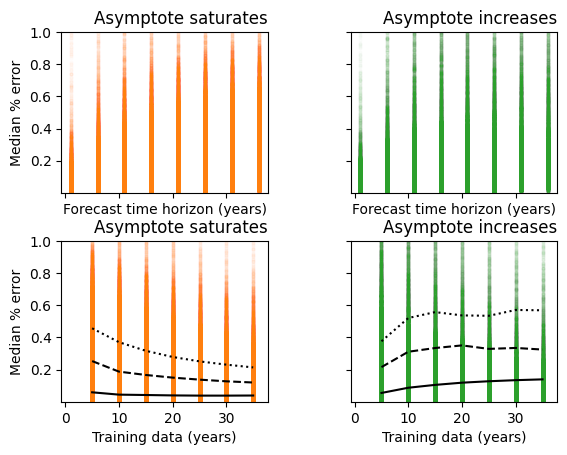

In [ ]:
fig, axs = plt.subplots(2,2, sharey = True, sharex=True)
plt.subplots_adjust(wspace=0.4, hspace=0.3)

axs[0,0].scatter(plotdata.loc[(plotdata['saturates'] == True), 'Length_test'], plotdata.loc[(plotdata['saturates'] == True), 'Hindcast_MAPE'], c = 'C1', alpha = 0.01, s = 5)
axs[0,1].scatter(plotdata.loc[(plotdata['saturates'] == False), 'Length_test'], plotdata.loc[(plotdata['saturates'] == False), 'Hindcast_MAPE'], c = 'C2', alpha = 0.01, s = 5)
axs[1,0].scatter(plotdata.loc[(plotdata['saturates'] == True), 'Length_train'], plotdata.loc[(plotdata['saturates'] == True), 'Hindcast_MAPE'], c = 'C1', alpha = 0.01, s = 5)
axs[1,1].scatter(plotdata.loc[(plotdata['saturates'] == False), 'Length_train'], plotdata.loc[(plotdata['saturates'] == False), 'Hindcast_MAPE'], c = 'C2', alpha = 0.01, s = 5)

axs[0,0].plot(medsatain0.index, medsatain0, c = 'black')
axs[0,0].plot(medsatain1.index, medsatain1, c = 'black', linestyle = 'dashed')
axs[0,0].plot(medsatain2.index, medsatain2, c = 'black', linestyle = 'dotted')
axs[0,1].plot(medunsain0.index, medunsain0, c = 'black')
axs[0,1].plot(medunsain1.index, medunsain1, c = 'black', linestyle = 'dashed')
axs[0,1].plot(medunsain2.index, medunsain2, c = 'black', linestyle = 'dotted')
axs[1,0].plot(medsatest1.index, medsatest0, c = 'black')
axs[1,0].plot(medsatest1.index, medsatest1, c = 'black', linestyle = 'dashed')
axs[1,0].plot(medsatest2.index, medsatest2, c = 'black', linestyle = 'dotted')
axs[1,1].plot(medunsest0.index, medunsest0, c = 'black')
axs[1,1].plot(medunsest1.index, medunsest1, c = 'black', linestyle = 'dashed')
axs[1,1].plot(medunsest2.index, medunsest2, c = 'black', linestyle = 'dotted')

# axs[0,0].set_yscale('log')
# axs[0,1].set_yscale('log')
# axs[1,0].set_yscale('log')
# axs[1,1].set_yscale('log')

plt.ylim(.000001,1)

axs[0,0].set_title('Asymptote saturates', loc = 'right')
axs[0,1].set_title('Asymptote increases', loc = 'right')
axs[1,0].set_title('Asymptote saturates', loc = 'right')
axs[1,1].set_title('Asymptote increases', loc = 'right')

axs[0,0].set_ylabel('Median % error')
axs[1,0].set_ylabel('Median % error')
axs[0,0].set_xlabel('Forecast time horizon (years)')
axs[0,1].set_xlabel('Forecast time horizon (years)')
axs[1,0].set_xlabel('Training data (years)')
axs[1,1].set_xlabel('Training data (years)')

plt.show()

## Old Figure 3

In [5]:
# train0 = 6
# train1 = 21
# train2 = 36

# test0 = [1]
test1 = [5]
# test2 = [10]
test3 = [15]
# test4 = [20]
test5 = [25]
# test6 = [30]
test7 = [35]

def mean_without_outlier(x): # x: series
    iqr = x.quantile(.75) - x.quantile(.25)
    y = x[x.between(x.quantile(.25) - 1.5*iqr, x.quantile(.75) + 1.5*iqr)]
    return y.mean()

In [16]:
plotdata = conthind.loc[(~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['Hindcast_MAPE', 'ar20', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()
# & (conthind['ar20'] < 0.9999) 
# (conthind['ar2_rank'] == 1) & 
# & (conthind['ar20'] > 0.6) 
plotdata['functional_form'].value_counts()

functional_form
logistic       27928
softplus       18586
linear         10345
exponential     7045
Name: count, dtype: int64

In [17]:
# medlin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test0)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlin1 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test1)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlin2 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test2)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlin3 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test3)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlin4 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test4)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlin5 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test5)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlin6 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test6)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlin7 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test7)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)

# medexp0 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test0)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medexp1 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test1)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medexp2 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test2)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medexp3 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test3)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medexp4 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test4)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medexp5 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test5)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medexp6 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test6)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medexp7 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test7)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)

# medlog0 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test0)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlog1 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test1)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlog2 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test2)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlog3 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test3)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlog4 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test4)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlog5 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test5)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medlog6 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test6)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medlog7 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test7)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)

# medsof0 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test0)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medsof1 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test1)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medsof2 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test2)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medsof3 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test3)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medsof4 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test4)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medsof5 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test5)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
# medsof6 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test6)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)
medsof7 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test7)), ['Length_train','Hindcast_MAPE']].groupby('Length_train').agg(mean_without_outlier)

p25lin = plotdata.loc[(plotdata['functional_form'] == 'linear'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
p75lin = plotdata.loc[(plotdata['functional_form'] == 'linear'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

p25exp = plotdata.loc[(plotdata['functional_form'] == 'exponential'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
p75exp = plotdata.loc[(plotdata['functional_form'] == 'exponential'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

p25log = plotdata.loc[(plotdata['functional_form'] == 'logistic'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
p75log = plotdata.loc[(plotdata['functional_form'] == 'logistic'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

p25sof = plotdata.loc[(plotdata['functional_form'] == 'softplus'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
p75sof = plotdata.loc[(plotdata['functional_form'] == 'softplus'),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25lin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75lin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25exp0 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75exp0 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25log0 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75log0 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25sof0 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75sof0 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test0)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25lin1 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75lin1 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25exp1 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75exp1 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25log1 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75log1 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25sof1 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75sof1 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test1)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25lin2 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75lin2 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25exp2 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75exp2 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25log2 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75log2 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)

# p25sof2 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.25)
# p75sof2 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test2)),].groupby('Length_train')['Hindcast_MAPE'].quantile(0.75)



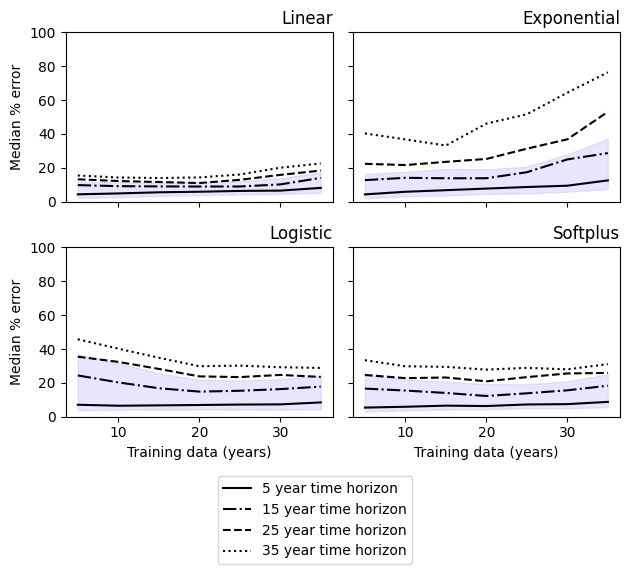

In [21]:
fig, axs = plt.subplots(2,2, sharey = True, sharex=True)
plt.subplots_adjust(wspace=0.4, hspace=0.3)

# axs[0,0].scatter(plotdata.loc[(plotdata['functional_form'] == 'linear'), 'Length_train'], plotdata.loc[(plotdata['functional_form'] == 'linear'), 'Hindcast_MAPE'], c = 'C2', alpha = 0.01, s = 5)
# axs[0,1].scatter(plotdata.loc[(plotdata['functional_form'] == 'exponential'), 'Length_train'], plotdata.loc[(plotdata['functional_form'] == 'exponential'), 'Hindcast_MAPE'], c = 'C3', alpha = 0.01, s = 5)
# axs[1,0].scatter(plotdata.loc[(plotdata['functional_form'] == 'logistic'), 'Length_train'], plotdata.loc[(plotdata['functional_form'] == 'logistic'), 'Hindcast_MAPE'], c = 'C6', alpha = 0.01, s = 5)
# axs[1,1].scatter(plotdata.loc[(plotdata['functional_form'] == 'softplus'), 'Length_train'], plotdata.loc[(plotdata['functional_form'] == 'softplus'), 'Hindcast_MAPE'], c = 'C8', alpha = 0.01, s = 5)

# axs[0,0].plot(medlin0.index, medlin0, c = 'black', label = '1 year time horizon')
axs[0,0].plot(medlin1.index, medlin1, c = 'black', label = '5 year time horizon')
# axs[0,0].plot(medlin2.index, medlin2, c = 'black', linestyle = 'dashdot', label = '10 year time horizon')
axs[0,0].plot(medlin3.index, medlin3, c = 'black', linestyle = 'dashdot', label = '15 year time horizon')
# axs[0,0].plot(medlin4.index, medlin4, c = 'black', linestyle = 'dashed', label = '20 year time horizon')
axs[0,0].plot(medlin5.index, medlin5, c = 'black', linestyle = 'dashed', label = '25 year time horizon')
# axs[0,0].plot(medlin6.index, medlin6, c = 'black', linestyle = 'dotted', label = '30 year time horizon')
axs[0,0].plot(medlin7.index, medlin7, c = 'black', linestyle = 'dotted', label = '35 year time horizon')

# axs[0,1].plot(medexp0.index, medexp0, c = 'black', label = '1-5 year time horizon')
axs[0,1].plot(medexp1.index, medexp1, c = 'black', label = '1-5 year time horizon')
# axs[0,1].plot(medexp2.index, medexp2, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[0,1].plot(medexp3.index, medexp3, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
# axs[0,1].plot(medexp4.index, medexp4, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[0,1].plot(medexp5.index, medexp5, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
# axs[0,1].plot(medexp6.index, medexp6, c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[0,1].plot(medexp7.index, medexp7, c = 'black', linestyle = 'dotted', label = '30-25 year time horizon')

# axs[1,0].plot(medlog0.index, medlog0, c = 'black', label = '1-5 year time horizon')
axs[1,0].plot(medlog1.index, medlog1, c = 'black', label = '1-5 year time horizon')
# axs[1,0].plot(medlog2.index, medlog2, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,0].plot(medlog3.index, medlog3, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
# axs[1,0].plot(medlog4.index, medlog4, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,0].plot(medlog5.index, medlog5, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
# axs[1,0].plot(medlog6.index, medlog6, c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[1,0].plot(medlog7.index, medlog7, c = 'black', linestyle = 'dotted', label = '30-25 year time horizon')

# axs[1,1].plot(medsof0.index, medsof0, c = 'black', label = '1-5 year time horizon')
axs[1,1].plot(medsof1.index, medsof1, c = 'black', label = '1-5 year time horizon')
# axs[1,1].plot(medsof2.index, medsof2, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,1].plot(medsof3.index, medsof3, c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
# axs[1,1].plot(medsof4.index, medsof4, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,1].plot(medsof5.index, medsof5, c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
# axs[1,1].plot(medsof6.index, medsof6, c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[1,1].plot(medsof7.index, medsof7, c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')

axs[0,0].fill_between(p25lin.index, y1=p25lin, y2=p75lin, color = 'xkcd:periwinkle', alpha = 0.2)
axs[0,1].fill_between(p25exp.index, y1=p25exp, y2=p75exp, color = 'xkcd:periwinkle', alpha = 0.2)
axs[1,0].fill_between(p25log.index, y1=p25log, y2=p75log, color = 'xkcd:periwinkle', alpha = 0.2)
axs[1,1].fill_between(p25sof.index, y1=p25sof, y2=p75sof, color = 'xkcd:periwinkle', alpha = 0.2)

# axs[0,0].fill_between(p25lin1.index, y1=p25lin1, y2=p75lin1, color = 'xkcd:bright blue', alpha = 0.2)
# axs[0,1].fill_between(p25exp1.index, y1=p25exp1, y2=p75exp1, color = 'xkcd:bright blue', alpha = 0.2)
# axs[1,0].fill_between(p25log1.index, y1=p25log1, y2=p75log1, color = 'xkcd:bright blue', alpha = 0.2)
# axs[1,1].fill_between(p25sof1.index, y1=p25sof1, y2=p75sof1, color = 'xkcd:bright blue', alpha = 0.2)

# axs[0,0].fill_between(p25lin2.index, y1=p25lin2, y2=p75lin2, color = 'xkcd:mint', alpha = 0.2)
# axs[0,1].fill_between(p25exp2.index, y1=p25exp2, y2=p75exp2, color = 'xkcd:mint', alpha = 0.2)
# axs[1,0].fill_between(p25log2.index, y1=p25log2, y2=p75log2, color = 'xkcd:mint', alpha = 0.2)
# axs[1,1].fill_between(p25sof2.index, y1=p25sof2, y2=p75sof2, color = 'xkcd:mint', alpha = 0.2)

# axs[0,0].set_yscale('log')
# axs[0,1].set_yscale('log')
# axs[1,0].set_yscale('log')
# axs[1,1].set_yscale('log')

plt.ylim(0,100)

axs[0,0].set_title('Linear', loc = 'right')
axs[0,1].set_title('Exponential', loc = 'right')
axs[1,0].set_title('Logistic', loc = 'right')
axs[1,1].set_title('Softplus', loc = 'right')

axs[0,0].set_ylabel('Median % error')
axs[1,0].set_ylabel('Median % error')
axs[1,0].set_xlabel('Training data (years)')
axs[1,1].set_xlabel('Training data (years)')

handles, labels = axs[0,0].get_legend_handles_labels()

fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.2))

plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()

In [66]:
print(len(plotdata['technology'].unique()))

371


In [47]:
techsforlog = plotdata.loc[plotdata['functional_form'] == 'logistic','technology'].unique()
techstocheck = plotdata.loc[plotdata['functional_form'].isin(['exponential', 'softplus', 'linear']),'technology'].unique()
print(sum(np.isin(techsforlog, techstocheck)))
print(len(techsforlog))
print(len(plotdata.loc[plotdata['functional_form'] == 'exponential','technology']))

293
352
7045


In [ ]:
#(~conthind['technology'].isin(out_tech)) & 
# & (conthind['technology'].isin(entechlist))
# & (conthind['MAPE_rank'] == 1)
plotdata = conthind.loc[(conthind['ar20'] > 0.9) & (conthind['ar20'] < 0.9999) & (conthind['MAPE_rank'] == 1) & (conthind['functional_form'].isin(['logistic', 'linear', 'exponential', 'bertalanffy'])), ['Hindcast_MAPE', 'ar20', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()

In [ ]:
train0 = 5
train1 = 20
train2 = 35

In [ ]:
medlin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medlin1 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medlin2 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

medexp0 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medexp1 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medexp2 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

medlog0 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medlog1 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medlog2 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

medber0 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train0), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medber1 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train1), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()
medber2 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train2), ['Length_test','Hindcast_MAPE']].groupby('Length_test').median()

In [ ]:
plotdata.columns

Index(['Hindcast_MAPE', 'ar20', 'Length_test', 'Length_train',
       'functional_form', 'technology'],
      dtype='object')

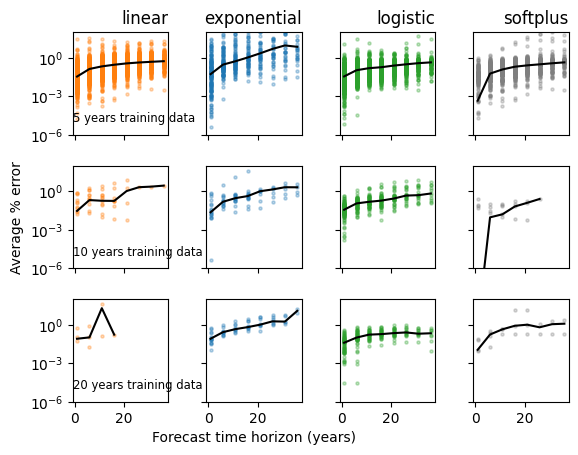

In [ ]:
fig, axs = plt.subplots(3,4, sharey = True, sharex=True)
plt.subplots_adjust(wspace=0.4, hspace=0.3)

axs[0,0].scatter(plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train0), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train0), 'Hindcast_MAPE'], c = 'C1', alpha = 0.3, s = 5)
axs[1,0].scatter(plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train1), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train1), 'Hindcast_MAPE'], c = 'C1', alpha = 0.3, s = 5)
axs[2,0].scatter(plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train2), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_train'] == train2), 'Hindcast_MAPE'], c = 'C1', alpha = 0.3, s = 5)
axs[0,1].scatter(plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train0), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train0), 'Hindcast_MAPE'], c = 'C0', alpha = 0.3, s = 5)
axs[1,1].scatter(plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train1), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train1), 'Hindcast_MAPE'], c = 'C0', alpha = 0.3, s = 5)
axs[2,1].scatter(plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train2), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_train'] == train2), 'Hindcast_MAPE'], c = 'C0', alpha = 0.3, s = 5)
axs[0,2].scatter(plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train0), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train0), 'Hindcast_MAPE'], c = 'C2', alpha = 0.3, s = 5)
axs[1,2].scatter(plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train1), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train1), 'Hindcast_MAPE'], c = 'C2', alpha = 0.3, s = 5)
axs[2,2].scatter(plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train2), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_train'] == train2), 'Hindcast_MAPE'], c = 'C2', alpha = 0.3, s = 5)
axs[0,3].scatter(plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train0), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train0), 'Hindcast_MAPE'], c = 'C7', alpha = 0.3, s = 5)
axs[1,3].scatter(plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train1), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train1), 'Hindcast_MAPE'], c = 'C7', alpha = 0.3, s = 5)
axs[2,3].scatter(plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train2), 'Length_test'], plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_train'] == train2), 'Hindcast_MAPE'], c = 'C7', alpha = 0.3, s = 5)

axs[0,0].plot(medlin0.index, medlin0, c = 'black')
axs[1,0].plot(medlin1.index, medlin1, c = 'black')
axs[2,0].plot(medlin2.index, medlin2, c = 'black')
axs[0,1].plot(medexp0.index, medexp0, c = 'black')
axs[1,1].plot(medexp1.index, medexp1, c = 'black')
axs[2,1].plot(medexp2.index, medexp2, c = 'black')
axs[0,2].plot(medlog0.index, medlog0, c = 'black')
axs[1,2].plot(medlog1.index, medlog1, c = 'black')
axs[2,2].plot(medlog2.index, medlog2, c = 'black')
axs[0,3].plot(medber0.index, medber0, c = 'black')
axs[1,3].plot(medber1.index, medber1, c = 'black')
axs[2,3].plot(medber2.index, medber2, c = 'black')

axs[0,0].set_yscale('log')
axs[1,0].set_yscale('log')
axs[2,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[1,1].set_yscale('log')
axs[2,1].set_yscale('log')
axs[0,2].set_yscale('log')
axs[1,2].set_yscale('log')
axs[2,2].set_yscale('log')
axs[0,3].set_yscale('log')
axs[1,3].set_yscale('log')
axs[2,3].set_yscale('log')

plt.ylim(.000001,100)

axs[0,0].set_title('linear', loc = 'right')
axs[0,1].set_title('exponential', loc = 'right')
axs[0,2].set_title('logistic', loc = 'right')
axs[0,3].set_title('softplus', loc = 'right')

axs[1,0].set_ylabel('Average % error')
axs[2,1].set_xlabel('Forecast time horizon (years)')

axs[0,0].text(-0.5, 0.00001, '5 years training data', fontsize = 'small')
axs[1,0].text(-0.5, 0.00001, '10 years training data', fontsize = 'small')
axs[2,0].text(-0.5, 0.00001, '20 years training data', fontsize = 'small')

plt.show()

## Old Figure 4

In [63]:
plotdata = conthind.loc[(~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['outside_CI', 'ar20', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()
# & (conthind['ar20'] < 0.9999) 
# (conthind['ar20'] > 0.9) & 
# & (conthind['ar2_rank'] == 1) 
# (conthind['ar20'] > 0.9) & 
# plotdata2 = plotdata.groupby(['functional_form', 'Length_test', 'Length_train'])['outside_CI'].apply(lambda x: (x == 0).sum()/len(x))

In [64]:
medlin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test0)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin1 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test1)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin2 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test2)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin3 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test3)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin4 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test4)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin5 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test5)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin6 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test6)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlin7 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test7)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))

medexp0 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test0)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp1 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test1)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp2 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test2)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp3 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test3)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp4 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test4)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp5 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test5)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp6 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test6)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medexp7 = plotdata.loc[(plotdata['functional_form'] == 'exponential') & (plotdata['Length_test'].isin(test7)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))

medlog0 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test0)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog1 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test1)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog2 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test2)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog3 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test3)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog4 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test4)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog5 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test5)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog6 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test6)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medlog7 = plotdata.loc[(plotdata['functional_form'] == 'logistic') & (plotdata['Length_test'].isin(test7)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))

medsof0 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test0)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof1 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test1)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof2 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test2)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof3 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test3)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof4 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test4)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof5 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test5)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof6 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test6)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
medsof7 = plotdata.loc[(plotdata['functional_form'] == 'softplus') & (plotdata['Length_test'].isin(test7)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))

medlin0.index

C:\Users\zacht\AppData\Local\Temp\ipykernel_21080\793584398.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  medlin0 = plotdata.loc[(plotdata['functional_form'] == 'linear') & (plotdata['Length_test'].isin(test0)), ['Length_train','outside_CI']].groupby('Length_train').apply(lambda x: (x == 0).sum()/len(x))
C:\Users\zacht\AppData\Local\Temp\ipykernel_21080\793584398.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence th

Index([5, 10, 15, 20, 25, 30, 35], dtype='int64', name='Length_train')

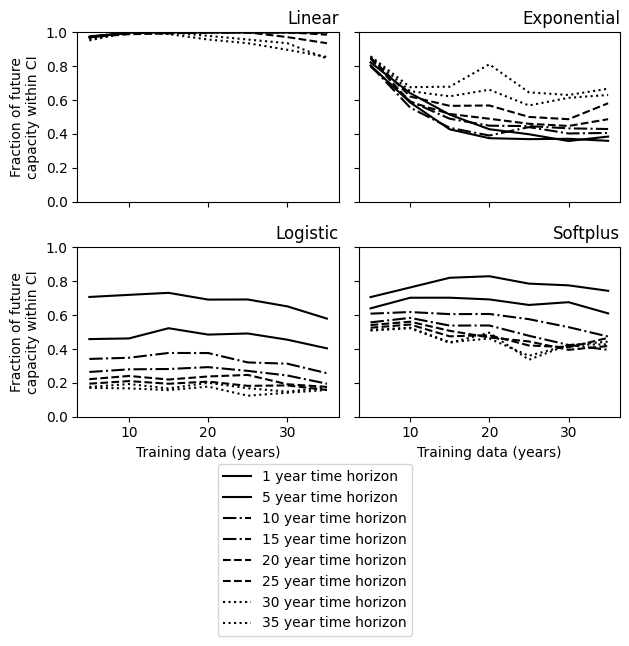

In [66]:
fig, axs = plt.subplots(2,2, sharey = True, sharex=True)
plt.subplots_adjust(wspace=0.4, hspace=0.3)

axs[0,0].plot(medlin0.index, medlin0['outside_CI'], c = 'black', label = '1 year time horizon')
axs[0,0].plot(medlin1.index, medlin1['outside_CI'], c = 'black', label = '5 year time horizon')
axs[0,0].plot(medlin2.index, medlin2['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10 year time horizon')
axs[0,0].plot(medlin3.index, medlin3['outside_CI'], c = 'black', linestyle = 'dashdot', label = '15 year time horizon')
axs[0,0].plot(medlin4.index, medlin4['outside_CI'], c = 'black', linestyle = 'dashed', label = '20 year time horizon')
axs[0,0].plot(medlin5.index, medlin5['outside_CI'], c = 'black', linestyle = 'dashed', label = '25 year time horizon')
axs[0,0].plot(medlin6.index, medlin6['outside_CI'], c = 'black', linestyle = 'dotted', label = '30 year time horizon')
axs[0,0].plot(medlin7.index, medlin7['outside_CI'], c = 'black', linestyle = 'dotted', label = '35 year time horizon')

axs[0,1].plot(medexp0.index, medexp0['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[0,1].plot(medexp1.index, medexp1['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[0,1].plot(medexp2.index, medexp2['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[0,1].plot(medexp3.index, medexp3['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[0,1].plot(medexp4.index, medexp4['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[0,1].plot(medexp5.index, medexp5['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[0,1].plot(medexp6.index, medexp6['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[0,1].plot(medexp7.index, medexp7['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-25 year time horizon')

axs[1,0].plot(medlog0.index, medlog0['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[1,0].plot(medlog1.index, medlog1['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[1,0].plot(medlog2.index, medlog2['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,0].plot(medlog3.index, medlog3['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,0].plot(medlog4.index, medlog4['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,0].plot(medlog5.index, medlog5['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,0].plot(medlog6.index, medlog6['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[1,0].plot(medlog7.index, medlog7['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-25 year time horizon')

axs[1,1].plot(medsof0.index, medsof0['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[1,1].plot(medsof1.index, medsof1['outside_CI'], c = 'black', label = '1-5 year time horizon')
axs[1,1].plot(medsof2.index, medsof2['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,1].plot(medsof3.index, medsof3['outside_CI'], c = 'black', linestyle = 'dashdot', label = '10-15 year time horizon')
axs[1,1].plot(medsof4.index, medsof4['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,1].plot(medsof5.index, medsof5['outside_CI'], c = 'black', linestyle = 'dashed', label = '20-25 year time horizon')
axs[1,1].plot(medsof6.index, medsof6['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')
axs[1,1].plot(medsof7.index, medsof7['outside_CI'], c = 'black', linestyle = 'dotted', label = '30-35 year time horizon')

plt.ylim(0,1)

axs[0,0].set_title('Linear', loc = 'right')
axs[0,1].set_title('Exponential', loc = 'right')
axs[1,0].set_title('Logistic', loc = 'right')
axs[1,1].set_title('Softplus', loc = 'right')

axs[0,0].set_ylabel('Fraction of future\ncapacity within CI')
axs[1,0].set_ylabel('Fraction of future\ncapacity within CI')
axs[1,0].set_xlabel('Training data (years)')
axs[1,1].set_xlabel('Training data (years)')

handles, labels = axs[0,0].get_legend_handles_labels()

fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.35))

plt.tight_layout(rect=[0, 0, 1, 1])

plt.show()

## Figure 4 contour

In [8]:
plotdata = conthind.loc[(conthind['Length_test'] < 35) & (conthind['Length_train'] < 35) & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['Hindcast_MAPE', 'Length_test', 'Length_train', 'functional_form']].dropna()

In [8]:
def mean_without_outlier(x): # x: series
    iqr = x.quantile(.95) - x.quantile(.05)
    y = x[x.between(x.quantile(.05) - 1.5*iqr, x.quantile(.95) + 1.5*iqr)]
    return x.median()

meanplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(mean_without_outlier)


C:\Users\zacht\AppData\Local\Temp\ipykernel_10536\2266574748.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  z[j,i] = meanplot.loc[(meanplot['functional_form'] == func) & (meanplot['Length_train'] == x[i]) & (meanplot['Length_test'] == y[j]),'Hindcast_MAPE']


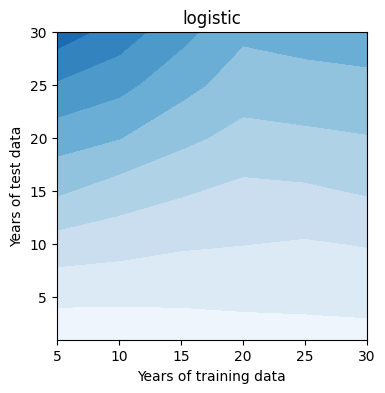

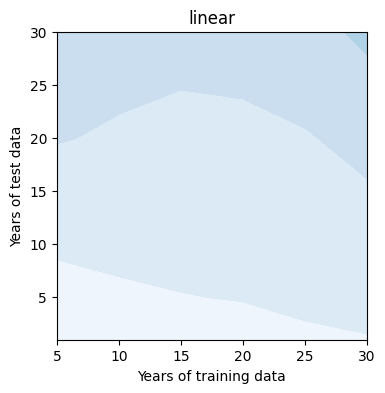

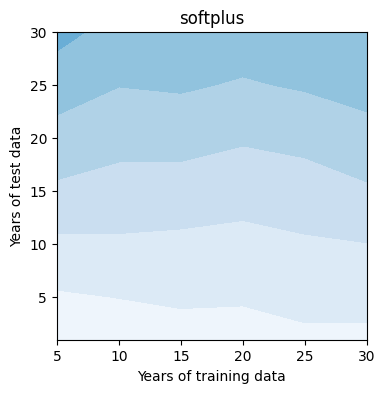

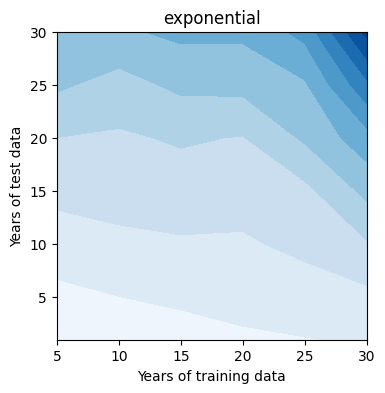

In [10]:
for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30]
    y = [1,5,10,15,20,25,30]
    # z = np.array(meanplot.loc[meanplot['functional_form'] == func,'Hindcast_MAPE'])
    # z = z.reshape(len(x), len(y)).transpose()
    z = np.ones((len(x), len(y))).transpose()
    for i in range(len(x)):
        for j in range(len(y)):
            z[j,i] = meanplot.loc[(meanplot['functional_form'] == func) & (meanplot['Length_train'] == x[i]) & (meanplot['Length_test'] == y[j]),'Hindcast_MAPE']
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55]) #,60,65,70,75,80,85,90,95
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.xlabel('Years of training data')
    plt.ylabel('Years of test data')
    

    # if save_fig:
    #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)



# cs = ax.contour('Length_train', 'Length_test', 'Hindcast_MAPE', data=phc)

# #medch.plot.scatter(x='Length_test',y='Length_train',ax=ax, c='Hindcast_MAPE', cmap='Blues')



C:\Users\zacht\AppData\Local\Temp\ipykernel_18416\4111835751.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 1 Axes> than <Figure size 100x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(CS, ax=ax)


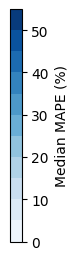

In [15]:
fig, ax = plt.subplots(figsize=(1,8))
cbar = plt.colorbar(CS, ax=ax)
cbar.set_label('Median MAPE (%)')
ax.remove()
plt.show()

### Figure S8

In [11]:
def sv_without_outlier(x): # x: series
    iqr = x.quantile(.95) - x.quantile(.05)
    y = x[x.between(x.quantile(.05) - 1.5*iqr, x.quantile(.95) + 1.5*iqr)]
    return x.quantile(0.75)

svplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(sv_without_outlier)


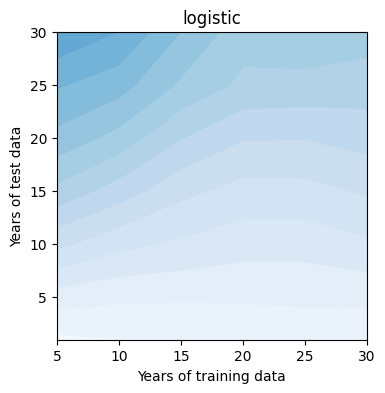

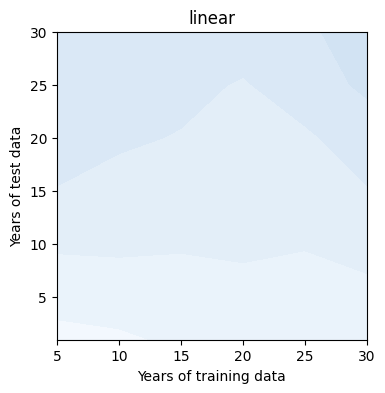

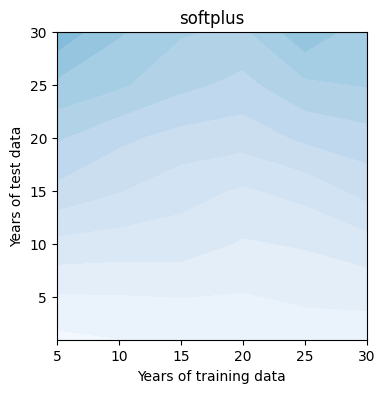

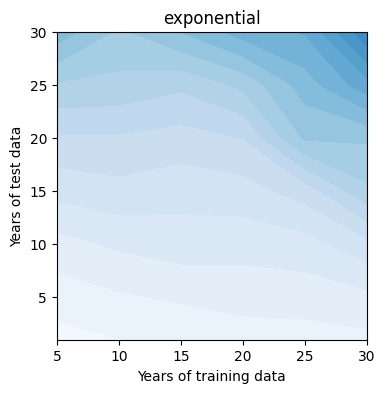

In [19]:
for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30]
    y = [1,5,10,15,20,25,30]
    z = np.array(svplot.loc[svplot['functional_form'] == func,'Hindcast_MAPE'])
    z = z.reshape(len(x), len(y)).transpose()
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120])
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.ylabel('Years of test data')
    plt.xlabel('Years of training data')

    # if save_fig:
    #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)




C:\Users\zacht\AppData\Local\Temp\ipykernel_10536\1770184930.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 1 Axes> than <Figure size 100x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(CS, ax=ax)


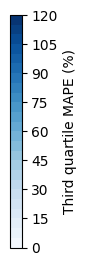

In [20]:
fig, ax = plt.subplots(figsize=(1,8))
cbar = plt.colorbar(CS, ax=ax)
cbar.set_label('Third quartile MAPE (%)')
ax.remove()
plt.show()

### Figure S9

In [21]:
def tv_without_outlier(x): # x: series
    iqr = x.quantile(.95) - x.quantile(.05)
    y = x[x.between(x.quantile(.05) - 1.5*iqr, x.quantile(.95) + 1.5*iqr)]
    return x.quantile(0.25)

tvplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(tv_without_outlier)

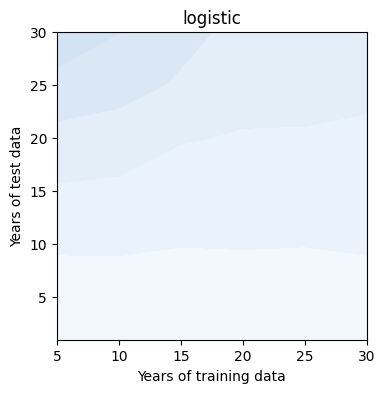

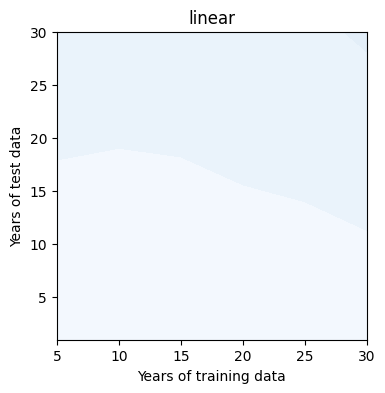

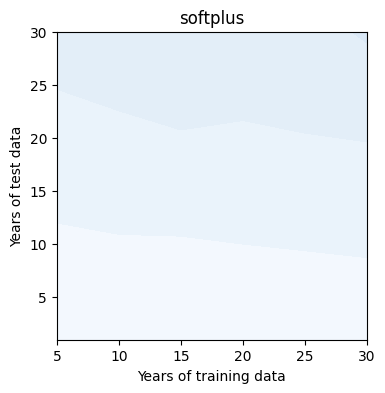

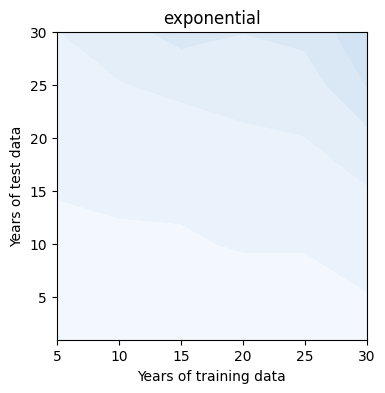

In [22]:
for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30]
    y = [1,5,10,15,20,25,30]
    z = np.array(tvplot.loc[tvplot['functional_form'] == func,'Hindcast_MAPE'])
    z = z.reshape(len(x), len(y)).transpose()
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120])
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.ylabel('Years of test data')
    plt.xlabel('Years of training data')

    # if save_fig:
    #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)



# cs = ax.contour('Length_train', 'Length_test', 'Hindcast_MAPE', data=phc)

# #medch.plot.scatter(x='Length_test',y='Length_train',ax=ax, c='Hindcast_MAPE', cmap='Blues')



C:\Users\zacht\AppData\Local\Temp\ipykernel_10536\609146589.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 1 Axes> than <Figure size 100x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(CS, ax=ax)


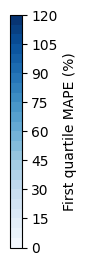

In [23]:
fig, ax = plt.subplots(figsize=(1,8))
cbar = plt.colorbar(CS, ax=ax)
cbar.set_label('First quartile MAPE (%)')
ax.remove()
plt.show()

### Figure S10

In [24]:
plotdata = conthind.loc[(~conthind['familyindex'].isin(family8_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['Hindcast_MAPE', 'Length_test', 'Length_train', 'functional_form']].dropna()

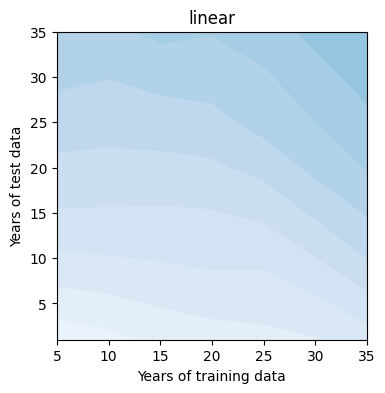

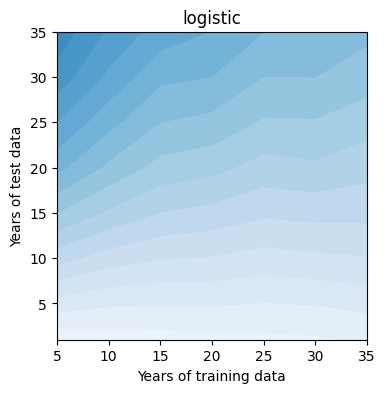

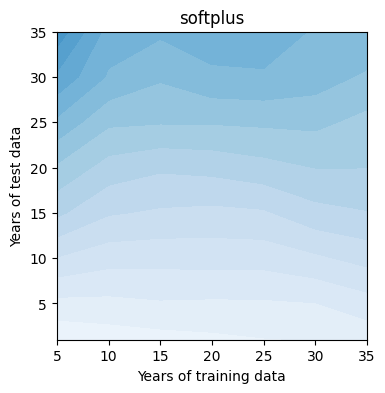

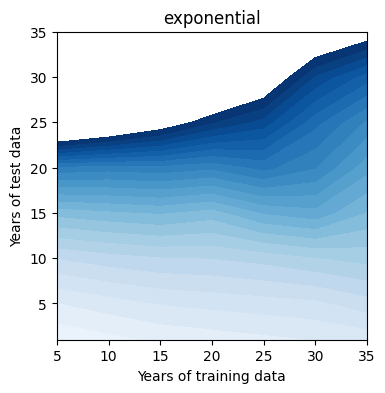

In [26]:
svplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(sv_without_outlier)
for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30,35]
    y = [1,5,10,15,20,25,30,35]
    z = np.array(svplot.loc[svplot['functional_form'] == func,'Hindcast_MAPE'])
    z = z.reshape(len(x), len(y)).transpose()
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120])
    # [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120]
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.ylabel('Years of test data')
    plt.xlabel('Years of training data')

    # if save_fig:
    #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)




C:\Users\zacht\AppData\Local\Temp\ipykernel_10536\609146589.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 1 Axes> than <Figure size 100x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(CS, ax=ax)


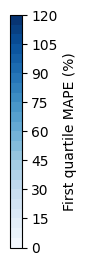

In [28]:
fig, ax = plt.subplots(figsize=(1,8))
cbar = plt.colorbar(CS, ax=ax)
cbar.set_label('First quartile MAPE (%)')
ax.remove()
plt.show()

### Figure S11

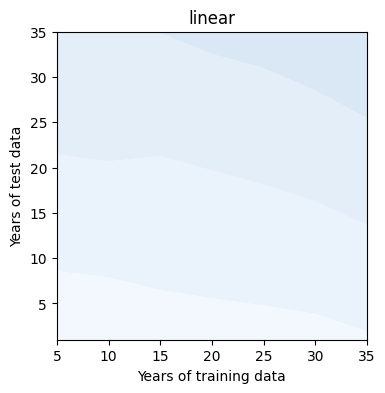

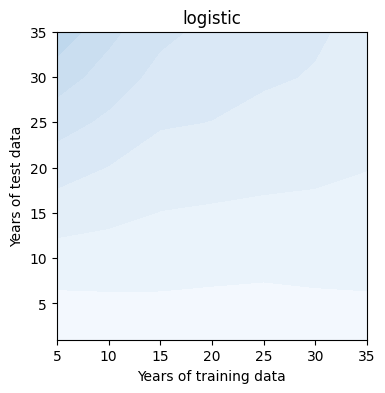

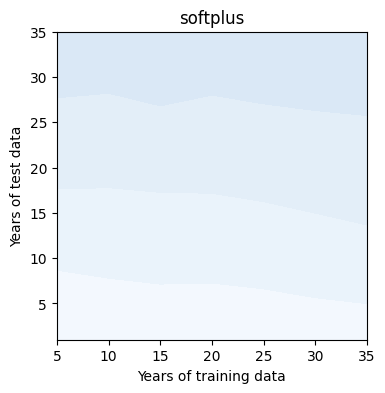

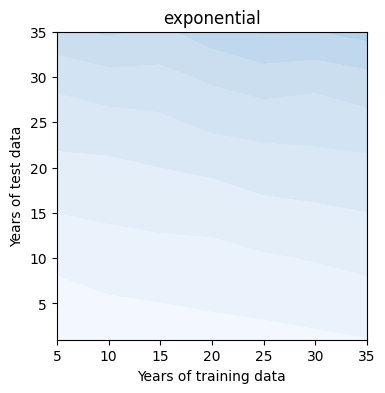

In [29]:
tvplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(tv_without_outlier)
for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30,35]
    y = [1,5,10,15,20,25,30,35]
    z = np.array(tvplot.loc[tvplot['functional_form'] == func,'Hindcast_MAPE'])
    z = z.reshape(len(x), len(y)).transpose()
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120])
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.ylabel('Years of test data')
    plt.xlabel('Years of training data')

    # if save_fig:
    #     plt.savefig(f'figures/{sample}_{day}_contMAPEstd_{func}.png', **savefig_settings)


### Figure S12

In [6]:
plotdata = conthind.loc[(~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['logistic', 'gompertz', 'bass', 'bertalanffy'])), ['Hindcast_MAPE', 'Length_test', 'Length_train', 'functional_form']].dropna()

ValueError: cannot reshape array of size 40 into shape (7,8)

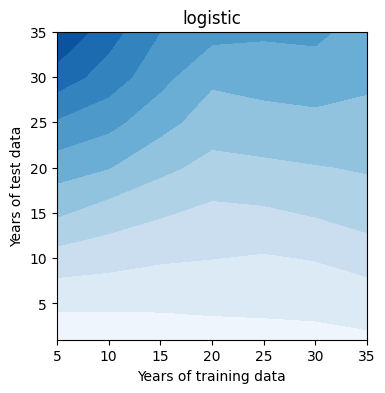

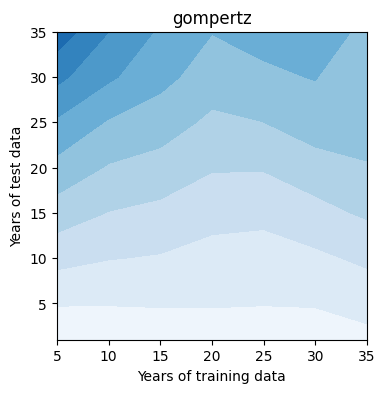

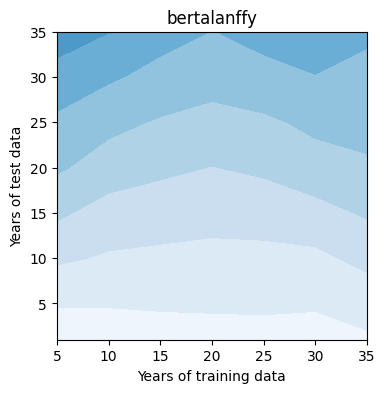

In [9]:
meanplot = plotdata.groupby(['Length_train', 'Length_test', 'functional_form'], as_index=False).agg(mean_without_outlier)

for func in plotdata['functional_form'].unique():
    x = [5,10,15,20,25,30,35]
    y = [1,5,10,15,20,25,30,35]
    z = np.array(meanplot.loc[meanplot['functional_form'] == func,'Hindcast_MAPE'])
    z = z.reshape(len(x), len(y)).transpose()
    X,Y = np.meshgrid(x,y)

    fig, ax = plt.subplots(figsize=(4,4))
    CS = ax.contourf(X,Y,z, cmap = "Blues", levels = [0,5,10,15,20,25,30,35,40,45,50,55])
    # CB = fig.colorbar(CS)
    plt.title(func)
    plt.ylabel('Years of test data')
    plt.xlabel('Years of training data')
    


C:\Users\zacht\AppData\Local\Temp\ipykernel_10536\4111835751.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 1 Axes> than <Figure size 100x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(CS, ax=ax)


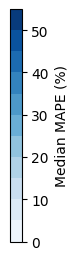

In [36]:
fig, ax = plt.subplots(figsize=(1,8))
cbar = plt.colorbar(CS, ax=ax)
cbar.set_label('Median MAPE (%)')
ax.remove()
plt.show()

## Figure 5

In [112]:
train_list = [5,10,20,30]
test_list = [1,10,20,30]

plotdata = conthind.loc[(conthind['Length_train'].isin(train_list)) & (conthind['Length_test'].isin(test_list)) & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['CI_size', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()
plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'] = abs(plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'])


C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packag

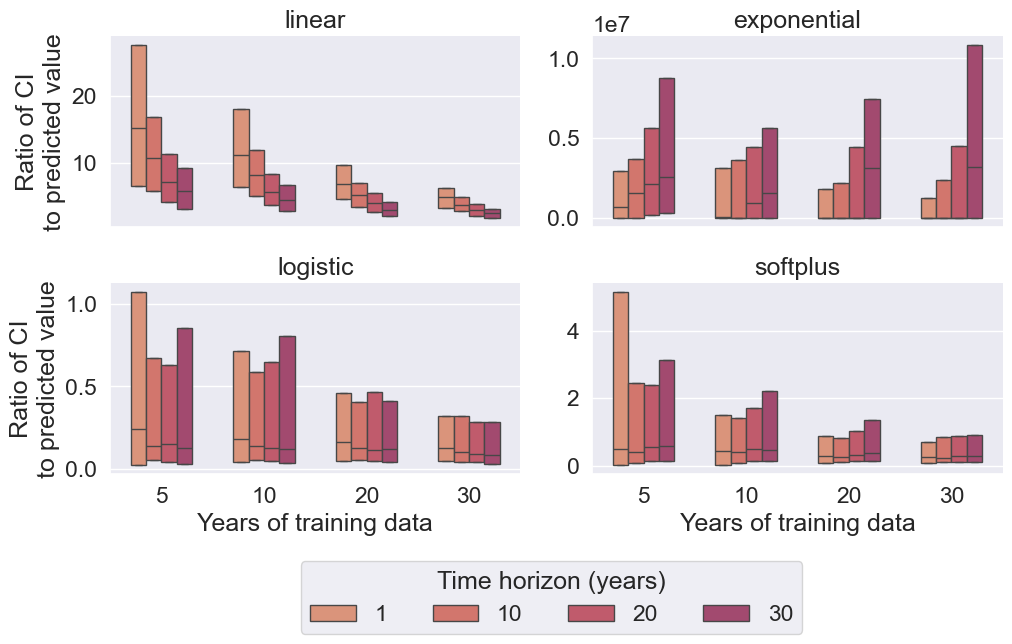

In [113]:
sns.set(font_scale=1.5)
g = sns.FacetGrid(plotdata, col='functional_form', sharey=False, col_order=['linear', 'exponential', 'logistic', 'softplus'], aspect=1.7, col_wrap= 2)
g.map(sns.boxplot, 'Length_train', 'CI_size', 'Length_test', showfliers=False,legend='full', width = 0.6, whis = 0, palette = sns.color_palette("flare")) #, orient = 'h'
g.set_axis_labels('Years of training data', 'Ratio of CI\nto predicted value')
g.set_titles("{col_name}")


plt.legend(ncol = 8, title = 'Time horizon (years)', loc='lower center',bbox_to_anchor=(-0.1,-0.9))
plt.show()

### Figure S13

In [115]:
train_list = [5,10,20,30]
test_list = [1,10,20,30]

plotdata = conthind.loc[(conthind['Length_train'].isin(train_list)) & (conthind['Length_test'].isin(test_list)) & (~conthind['familyindex'].isin(family8_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['linear', 'exponential', 'logistic', 'softplus'])), ['CI_size', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()
plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'] = abs(plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'])

C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packag

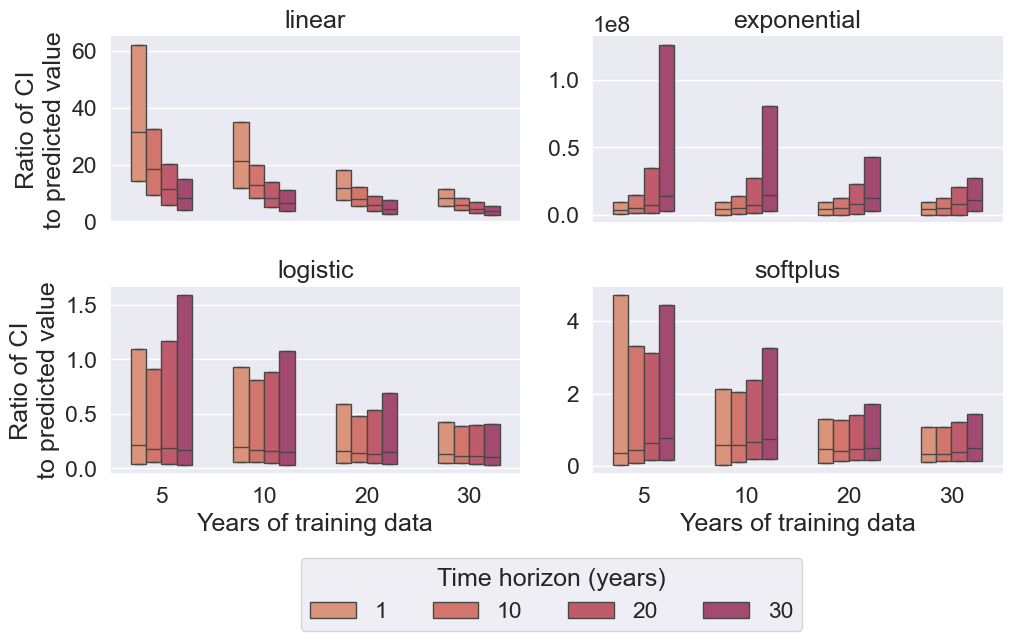

In [116]:
sns.set(font_scale=1.5)
g = sns.FacetGrid(plotdata, col='functional_form', sharey=False, col_order=['linear', 'exponential', 'logistic', 'softplus'], aspect=1.7, col_wrap= 2)
g.map(sns.boxplot, 'Length_train', 'CI_size', 'Length_test', showfliers=False,legend='full', width = 0.6, whis = 0, palette = sns.color_palette("flare")) #, orient = 'h'
g.set_axis_labels('Years of training data', 'Ratio of CI\nto predicted value')
g.set_titles("{col_name}")


plt.legend(ncol = 8, title = 'Time horizon (years)', loc='lower center',bbox_to_anchor=(-0.1,-0.9))
plt.show()

### Figure S14

In [163]:
asdf = conthind.loc[(conthind['Length_train'].isin(train_list)) & (conthind['Length_test'].isin(test_list)) & (~conthind['familyindex'].isin(family0_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin([ 'bass'])), ['CI_size', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()

In [171]:
train_list = [5,10,20,30]
test_list = [1,10,20,30]
# & (~conthind['familyindex'].isin(family0_list))
plotdata = conthind.loc[(conthind['Length_train'].isin(train_list)) & (conthind['Length_test'].isin(test_list)) & (conthind['technology'].isin(technology_list)) & (conthind['functional_form'].isin(['logistic', 'gompertz', 'bass', 'bertalanffy'])), ['CI_size', 'Length_test', 'Length_train', 'functional_form', 'technology']].dropna()
plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'] = abs(plotdata.loc[plotdata['CI_size'] < 0, 'CI_size'])

C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packag

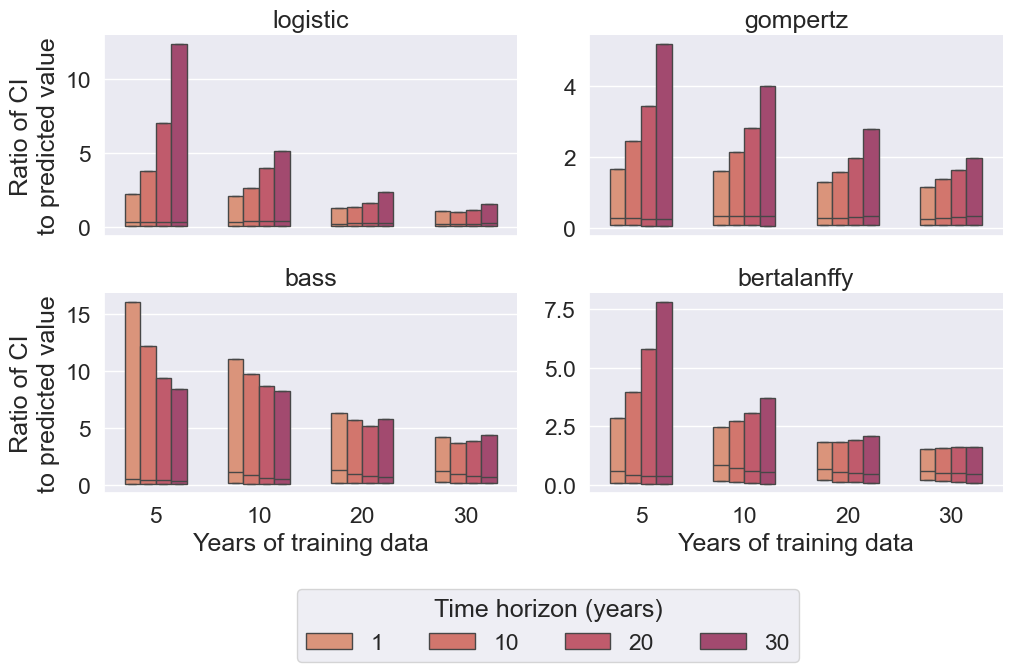

In [172]:
sns.set(font_scale=1.5)
g = sns.FacetGrid(plotdata, col='functional_form', sharey=False, col_order=['logistic', 'gompertz', 'bass', 'bertalanffy'], aspect=1.7, col_wrap= 2)
g.map(sns.boxplot, 'Length_train', 'CI_size', 'Length_test', showfliers=False,legend='full', width = 0.6, whis = 0, palette = sns.color_palette("flare")) #, orient = 'h'
g.set_axis_labels('Years of training data', 'Ratio of CI\nto predicted value')
g.set_titles("{col_name}")


plt.legend(ncol = 8, title = 'Time horizon (years)', loc='lower center',bbox_to_anchor=(-0.1,-0.9))
plt.show()

# Other continuous plots

In [13]:
conthind.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flag', 'technology', 'Start_index',
       'Length_train', 'Length_test', 'Hindcast_MAPE', 'outside_CI', 'CI_size',
       'd', 'd_std', 'error_type', 'error_msg', 'sigmoid_r2', 'log_test_MAPE',
       'ar20', 'ar2_rank', 'bestlog', 'adj_r2_bin', 'fitindex', 'MAPE_rank',
       'add_score', 'add_rank', 'saturates', 'familyindex', 'maxlength'],
      dtype='object')

In [ ]:
plotdata = conthind.loc[conthind['functional_form'] == "logistic", ['Length_train', 'Length_test', 'log_test_MAPE', 'adj_r2_bin']].dropna()

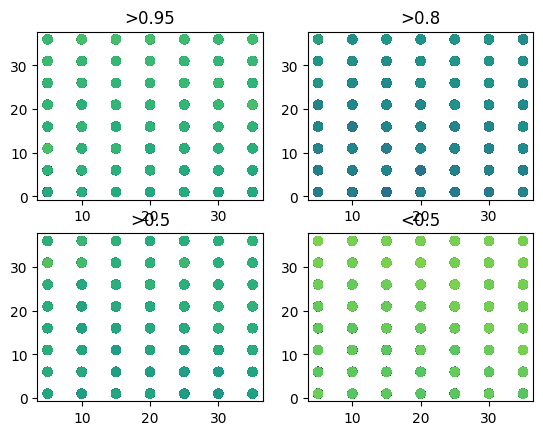

In [ ]:
fig, axs = plt.subplots(2,2)
axs[0,0].scatter(plotdata.loc[plotdata['adj_r2_bin'] == '>0.95', 'Length_train'], plotdata.loc[plotdata['adj_r2_bin'] == '>0.95', 'Length_test'], c = plotdata.loc[plotdata['adj_r2_bin'] == '>0.95', 'log_test_MAPE'], cmap = 'viridis', alpha = 0.3)
axs[0,1].scatter(plotdata.loc[plotdata['adj_r2_bin'] == '>0.8', 'Length_train'], plotdata.loc[plotdata['adj_r2_bin'] == '>0.8', 'Length_test'], c = plotdata.loc[plotdata['adj_r2_bin'] == '>0.8', 'log_test_MAPE'], cmap = 'viridis', alpha = 0.3)
axs[1,0].scatter(plotdata.loc[plotdata['adj_r2_bin'] == '>0.5', 'Length_train'], plotdata.loc[plotdata['adj_r2_bin'] == '>0.5', 'Length_test'], c = plotdata.loc[plotdata['adj_r2_bin'] == '>0.5', 'log_test_MAPE'], cmap = 'viridis', alpha = 0.3)
axs[1,1].scatter(plotdata.loc[plotdata['adj_r2_bin'] == '<0.5', 'Length_train'], plotdata.loc[plotdata['adj_r2_bin'] == '<0.5', 'Length_test'], c = plotdata.loc[plotdata['adj_r2_bin'] == '<0.5', 'log_test_MAPE'], cmap = 'viridis', alpha = 0.3)

axs[0,0].set_title('>0.95')
axs[0,1].set_title('>0.8')
axs[1,0].set_title('>0.5')
axs[1,1].set_title('<0.5')

plt.show()

In [ ]:
plotdata = conthind.loc[conthind['functional_form'] == "logistic", ['Length_train', 'Length_test', 'log_test_MAPE', 'ar20']].dropna()

In [85]:
#plot subset where logistic is the best fit

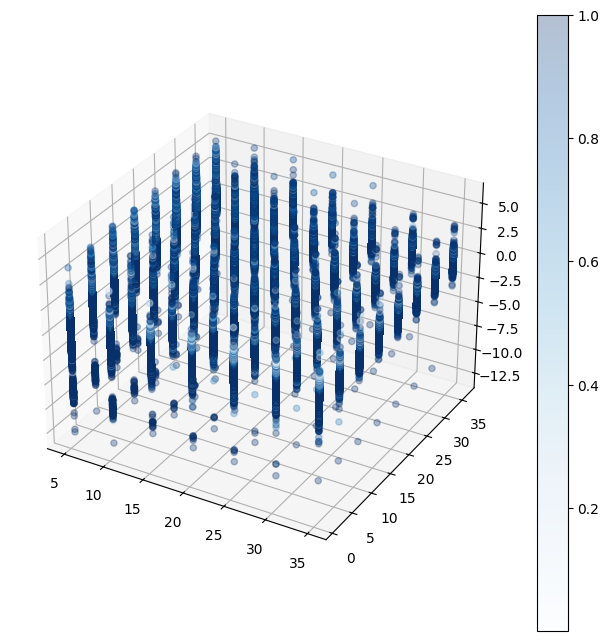

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(plotdata['Length_train'], plotdata['Length_test'], plotdata['log_test_MAPE'], c=plotdata['ar20'], cmap='Blues', alpha = 0.3) #, alpha = plotdata['ar20']

# ax.set_xlabel('Length of training data')
# ax.set_ylabel('Length of test data')
# ax.set_zlabel('Log of percent accuracy of test data')

plt.colorbar(scatter)
plt.show()

Text(0.5, 29.140624999999986, 'Length of test data')

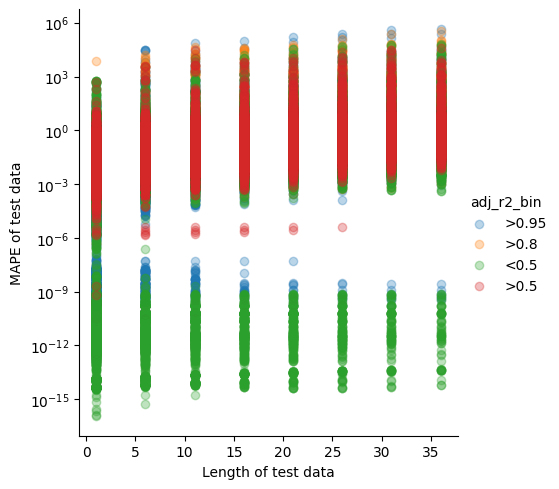

In [31]:
plotdata = conthind[conthind['functional_form'] == "logistic"]
sns.lmplot(x = 'Length_test', y = 'Hindcast_MAPE', data = plotdata, hue = 'adj_r2_bin', fit_reg=False, scatter_kws= {'alpha' : 0.3})

plt.yscale('log')
plt.ylabel('MAPE of test data')
plt.xlabel('Length of test data')

# Regress MAPE ~ Train length + Train R2 + Test length

In [48]:
#Include technologies that ever have > 40 years of data
conthind['long'] = conthind['technology'].isin(conthind.loc[(conthind['Length_train'] + conthind['Length_test']) > 40, 'technology'].unique())

conthind['n_params'] = np.nan
conthind.loc[conthind['functional_form'].isin(['linear', 'exponential']), 'n_params'] = 2
conthind.loc[conthind['functional_form'].isin(['logistic', 'gompertz', 'softplus', 'logistic-linear-cont']), 'n_params'] = 3
conthind.loc[conthind['functional_form'].isin(['bass', 'bertalanffy', 'richards']), 'n_params'] = 4



conthind.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flag', 'technology', 'Start_index',
       'Length_train', 'Length_test', 'Hindcast_MAPE', 'outside_CI', 'CI_size',
       'd', 'd_std', 'error_type', 'error_msg', 'sigmoid_r2', 'log_test_MAPE',
       'ar20', 'ar2_rank', 'bestlog', 'adj_r2_bin', 'fitindex', 'MAPE_rank',
       'add_score', 'add_rank', 'saturates', 'familyindex', 'maxlength',
       'long', 'n_params'],
      dtype='object')

## Table S4

In [ ]:
regdf = conthind.loc[(conthind['Length_train'] < 25) & (conthind['Length_test'] < 25) &(conthind['saturates'] == True) & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)
#(conthind['Length_train'] < 25) & (conthind['Length_test'] < 25) &

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

ValueError: zero-size array to reduction operation maximum which has no identity

In [16]:
regdf = conthind.loc[(conthind['Length_train'] < 25) & (conthind['Length_test'] < 25) &(conthind['functional_form'] == 'softplus') & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test ', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     1551.
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:04:47   Log-Likelihood:                -9857.6
No. Observations:                9842   AIC:                         1.972e+04
Df Residuals:                    9839   BIC:                         1.974e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.8580      0.018   -104.779   

In [9]:
regdf = conthind.loc[(conthind['Length_train'] < 25) & (conthind['Length_test'] < 25) &(~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     615.8
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:52:07   Log-Likelihood:            -1.4564e+05
No. Observations:               68909   AIC:                         2.913e+05
Df Residuals:                   68905   BIC:                         2.913e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [21]:
regdf = conthind.loc[(conthind['saturates'] == True) & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     5127.
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:31:11   Log-Likelihood:                -75925.
No. Observations:               74983   AIC:                         1.519e+05
Df Residuals:                   74977   BIC:                         1.519e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [22]:
regdf = conthind.loc[(conthind['saturates'] == False) & (~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     278.8
Date:                Tue, 23 Dec 2025   Prob (F-statistic):          1.87e-295
Time:                        13:32:20   Log-Likelihood:            -1.2871e+05
No. Observations:               54267   AIC:                         2.574e+05
Df Residuals:                   54261   BIC:                         2.575e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [23]:
regdf = conthind.loc[(~conthind['familyindex'].isin(family_list)) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     744.9
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:33:51   Log-Likelihood:            -2.6920e+05
No. Observations:              129250   AIC:                         5.384e+05
Df Residuals:                  129244   BIC:                         5.385e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## Table S5

In [24]:
regdf = conthind.loc[(conthind['saturates'] == True) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                 1.154e+05
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:34:39   Log-Likelihood:            -1.3541e+06
No. Observations:             1451734   AIC:                         2.708e+06
Df Residuals:                 1451730   BIC:                         2.708e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [25]:
regdf = conthind.loc[(conthind['saturates'] == False) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                 1.092e+04
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:35:08   Log-Likelihood:            -2.4787e+06
No. Observations:             1278737   AIC:                         4.957e+06
Df Residuals:                 1278733   BIC:                         4.957e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [26]:
regdf = conthind.loc[(conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                 4.355e+04
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:35:38   Log-Likelihood:            -4.6123e+06
No. Observations:             2730471   AIC:                         9.225e+06
Df Residuals:                 2730467   BIC:                         9.225e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [27]:
regdf = conthind.loc[(conthind['saturates'] == True) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                 7.830e+04
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:36:10   Log-Likelihood:            -1.3361e+06
No. Observations:             1451734   AIC:                         2.672e+06
Df Residuals:                 1451728   BIC:                         2.672e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [28]:
regdf = conthind.loc[(conthind['saturates'] == False) & (conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     7613.
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:37:48   Log-Likelihood:            -2.4761e+06
No. Observations:             1278737   AIC:                         4.952e+06
Df Residuals:                 1278731   BIC:                         4.952e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [29]:
regdf = conthind.loc[(conthind['technology'].isin(technology_list)), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] == False) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train + Length_test + Length_train*Length_test + ar20 + Length_train*ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                 2.670e+04
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:38:26   Log-Likelihood:            -4.6109e+06
No. Observations:             2730471   AIC:                         9.222e+06
Df Residuals:                 2730465   BIC:                         9.222e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## Past regressions

In [57]:
regdf = conthind.loc[(conthind['ar20'] > 0) & (conthind['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] = True) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                 6.460e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:33:16   Log-Likelihood:            -5.8729e+06
No. Observations:             3474483   AIC:                         1.175e+07
Df Residuals:                 3474479   BIC:                         1.175e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.6565      0.003   -244.085   

In [60]:
regdf = conthind.loc[(conthind['saturates'] == False) & (conthind['ar20'] > 0) & (conthind['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] = True) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                 1.987e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:36:02   Log-Likelihood:            -3.1425e+06
No. Observations:             1633611   AIC:                         6.285e+06
Df Residuals:                 1633607   BIC:                         6.285e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.6310      0.005   -135.214   

In [140]:
regdf = conthind.loc[(conthind['saturates'] == False) & (conthind['ar20'] > 0.9) & (conthind['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()
#(conthind['long'] == True) & 
#(conthind['saturates'] = True) & 
# & (conthind['ar2_rank'] == 1)

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     5829.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        16:22:47   Log-Likelihood:            -1.4592e+06
No. Observations:              680576   AIC:                         2.918e+06
Df Residuals:                  680572   BIC:                         2.919e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.2683      0.084    -74.457   

# Regression of metadata on hindcasting results

In [3]:
hatch = read_hatch.read_hatch('data/HATCH_v1.5_clean.csv')

meta_data_cols = hatch.columns[:8]
meta_data_cols

Removed timeseries with less than 10 data points: 1681
Removed timeseries with constant values: 68
Removed data within the following number of timeseries that are during the formative phase:


Index(['Spatial Scale', 'Region', 'Country Name', 'Technology Name', 'Metric',
       'Unit', 'Data Source', 'Long Technology Name'],
      dtype='object')

In [142]:
ch_meta = pd.merge(conthind, hatch[meta_data_cols], left_on='technology', right_index=True, how="left", )
# ch_meta.head()

In [143]:
ch_meta['Metric'] = ch_meta['Metric'].replace({'Annual production': 'Annual Production',
                                               'Cumulative total capacity': 'Cumulative Total Capacity'})
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
ch_meta['metric_grouped'] = ch_meta['Metric'].map(group_metrics)

In [144]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'annual') & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                 1.165e+04
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        16:24:08   Log-Likelihood:            -1.0375e+06
No. Observations:              582232   AIC:                         2.075e+06
Df Residuals:                  582228   BIC:                         2.075e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0135      0.065     -0.208   

In [145]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'annual') & (ch_meta['saturates'] == True) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                 3.258e+04
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        16:25:13   Log-Likelihood:            -3.4163e+05
No. Observations:              344416   AIC:                         6.833e+05
Df Residuals:                  344412   BIC:                         6.833e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8770      0.039     22.769   

In [146]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'annual') & (ch_meta['saturates'] == False) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2986.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        16:25:17   Log-Likelihood:            -4.9329e+05
No. Observations:              237816   AIC:                         9.866e+05
Df Residuals:                  237812   BIC:                         9.866e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.0984      0.136    -22.805   

In [118]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'cumulative') & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 1.442e+04
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:52:21   Log-Likelihood:            -2.1054e+06
No. Observations:             1126175   AIC:                         4.211e+06
Df Residuals:                 1126171   BIC:                         4.211e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.7952      0.052    -15.401   

In [119]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'cumulative') & (ch_meta['saturates'] == True) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                 6.542e+04
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:55:15   Log-Likelihood:            -6.4359e+05
No. Observations:              644253   AIC:                         1.287e+06
Df Residuals:                  644249   BIC:                         1.287e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.9717      0.029     68.229   

In [120]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'cumulative') & (ch_meta['saturates'] == False) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     4196.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:55:18   Log-Likelihood:            -1.0321e+06
No. Observations:              481922   AIC:                         2.064e+06
Df Residuals:                  481918   BIC:                         2.064e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -7.3578      0.103    -71.705   

In [121]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'share') & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     4950.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:55:27   Log-Likelihood:            -1.3495e+05
No. Observations:               81860   AIC:                         2.699e+05
Df Residuals:                   81856   BIC:                         2.699e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.8259      0.148     39.272   

In [122]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'share') & (ch_meta['saturates'] == True) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     3371.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:55:54   Log-Likelihood:                -97948.
No. Observations:               63133   AIC:                         1.959e+05
Df Residuals:                   63129   BIC:                         1.959e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.3491      0.155     34.514   

In [123]:
regdf = ch_meta.loc[(ch_meta['metric_grouped'] == 'share') & (ch_meta['saturates'] == False) & (ch_meta['ar20'] > 0.9) & (ch_meta['ar20'] < 1), ['log_test_MAPE', 'ar20', 'Length_train', 'Length_test']].dropna()

model = smf.ols(formula='log_test_MAPE ~ Length_train  + Length_test + ar20', data = regdf, missing = 'drop')
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_test_MAPE   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     1028.
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        15:55:58   Log-Likelihood:                -30250.
No. Observations:               18727   AIC:                         6.051e+04
Df Residuals:                   18723   BIC:                         6.054e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.9866      0.294      6.758   